# AgriIntel — Phase 1: Exploratory Data Analysis
### Aurelius Consulting & Analytics Club | ML Track 2026

**Input:** `train_data.csv`  
**Goal:** Understand the data before cleaning or modelling — distributions, missing values, outliers, categorical patterns, and seasonal structure.

---

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/drive/MyDrive/train_data_1.csv')
TARGET = 'Target_Variable/Total Income'

df.head(3)

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000


## 1. Data Quality Audit
### 1.1 Missing Values

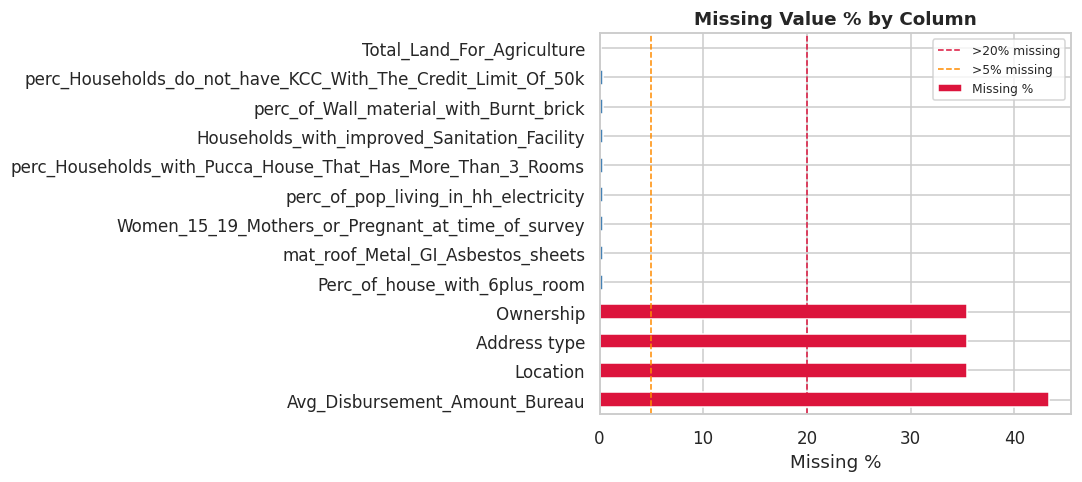

,Missing Count,Missing %
Avg_Disbursement_Amount_Bureau,18706,43.33
Location,15315,35.47
Address type,15315,35.47
Ownership,15315,35.47
Perc_of_house_with_6plus_room,154,0.36
mat_roof_Metal_GI_Asbestos_sheets,154,0.36
Women_15_19_Mothers_or_Pregnant_at_time_of_survey,154,0.36
perc_of_pop_living_in_hh_electricity,154,0.36
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,154,0.36
Households_with_improved_Sanitation_Facility,154,0.36


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.35)))

colors = ['crimson' if p > 20 else 'darkorange' if p > 5 else 'steelblue'
          for p in missing_df['Missing %']]

missing_df['Missing %'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(20, color='crimson', linestyle='--', linewidth=1, label='>20% missing')
ax.axvline(5,  color='darkorange', linestyle='--', linewidth=1, label='>5% missing')
ax.set_title('Missing Value % by Column', fontsize=12, fontweight='bold')
ax.set_xlabel('Missing %')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

missing_df

**Insight:** `Avg_Disbursement_Amount_Bureau` has ~43% missing values — this likely means the farmer has no bureau record, not that the data was forgotten. `Location`, `Address type`, and `Ownership` are around 35% missing, probably because they weren't collected for all loan types. Everything else has under 1% missing and can be safely filled with median or mode.

### 1.2 Duplicate Records

In [ ]:
dup_rows = df.duplicated().sum()
dup_ids  = df['FarmerID'].duplicated().sum()

print(f'Fully duplicate rows : {dup_rows}')
print(f'Duplicate FarmerIDs  : {dup_ids}')

if dup_ids > 0:
    dup_farmers = df[df['FarmerID'].duplicated(keep=False)].sort_values('FarmerID')
    print(dup_farmers[['FarmerID', 'State', 'Total_Land_For_Agriculture', TARGET]].head(8))

Fully duplicate rows : 2
Duplicate FarmerIDs  : 14
               FarmerID          State  Total_Land_For_Agriculture  \
33109  1047232142240080      KARNATAKA                        20.0   
33444  1047232142240080      KARNATAKA                        20.0   
34792  2417539487235010  UTTAR PRADESH                         4.0   
26656  2417539487235010  UTTAR PRADESH                         4.0   
12009  3488965833644730  UTTAR PRADESH                         4.0   
22948  3488965833644730  UTTAR PRADESH                         4.0   
32323  3997939085103370        HARYANA                        12.0   
15036  3997939085103370        HARYANA                        12.0   

       Target_Variable/Total Income  
33109                       1200000  
33444                       1200000  
34792                        700000  
26656                        700000  
12009                        600000  
22948                        600000  
32323                       1444500  
15036         

**Insight:** A small number of fully duplicate rows exist and should be dropped. Duplicate FarmerIDs could be re-applications or data entry errors — worth investigating which record to keep.

### 1.3 Data Types & Column Categories

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop(['FarmerID', 'Zipcode', TARGET], errors='ignore').tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print()
print('Dtype breakdown:')
print(df.dtypes.value_counts())

temp_cols = [c for c in cat_cols if 'temperature' in c.lower()]
if temp_cols:
    print()
    print('Temperature columns (stored as strings):')
    print(df[temp_cols[0]].dropna().head(5).values)

Numerical features  : 64
Categorical features: 38

Dtype breakdown:
float64    62
object     38
int64       5
Name: count, dtype: int64

Temperature columns (stored as strings):
['23.88 /30' '24.63 /31.27' '25.23 /31.83' '24.04 /32.19' '24.42 /30.91']


**Insight:** Temperature columns are stored as strings like `"24.63 /31.27"` — they need to be split into two numeric columns (`temp_min` and `temp_max`) in Phase 2.

## 2. Target Variable Analysis
### 2.1 Distribution & Skewness

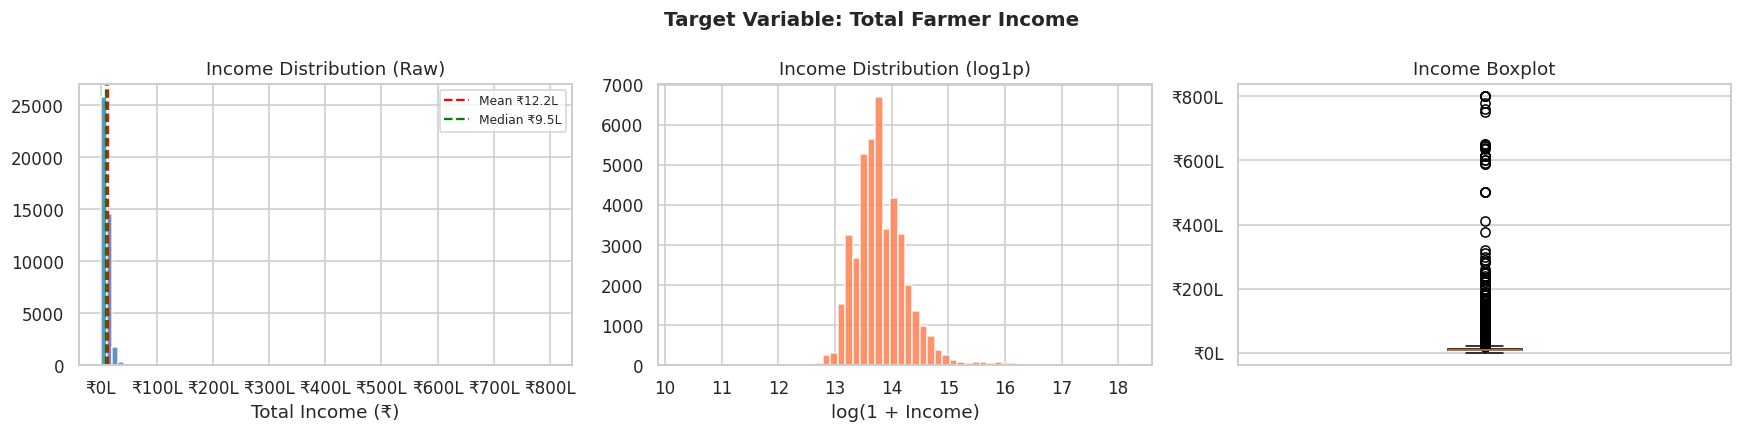

Mean     : ₹   1,222,379
Median   : ₹     950,000
Std Dev  : ₹   2,064,511
Skewness : 23.151
Min      : ₹      29,000
Max      : ₹  80,000,000


In [ ]:
target = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(target, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(target.mean(),   color='red',   linestyle='--', label=f'Mean ₹{target.mean()/1e5:.1f}L')
axes[0].axvline(target.median(), color='green', linestyle='--', label=f'Median ₹{target.median()/1e5:.1f}L')
axes[0].set_title('Income Distribution (Raw)')
axes[0].set_xlabel('Total Income (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].legend(fontsize=8)

log_target = np.log1p(target)
axes[1].hist(log_target, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Income Distribution (log1p)')
axes[1].set_xlabel('log(1 + Income)')

axes[2].boxplot(target, vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[2].set_title('Income Boxplot')
axes[2].set_xticks([])

plt.suptitle('Target Variable: Total Farmer Income', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean     : ₹{target.mean():>12,.0f}')
print(f'Median   : ₹{target.median():>12,.0f}')
print(f'Std Dev  : ₹{target.std():>12,.0f}')
print(f'Skewness : {target.skew():.3f}')
print(f'Min      : ₹{target.min():>12,.0f}')
print(f'Max      : ₹{target.max():>12,.0f}')

**Insight:** Income is strongly right-skewed (skew > 5). The mean sits well above the median because a small group of high-income farmers pulls it up. The model should be trained on `log1p(income)` and predictions converted back using `expm1()`. This matters especially for MAPE — a ₹50k error on a ₹1L income is 50% error.

### 2.2 Outlier Detection in Target

In [ ]:
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 3 * IQR
lower_fence = Q1 - 3 * IQR

outliers_high = (target > upper_fence).sum()
outliers_low  = (target < lower_fence).sum()

print(f'Upper fence (3×IQR): ₹{upper_fence:,.0f}')
print(f'Lower fence (3×IQR): ₹{lower_fence:,.0f}')
print(f'Outliers above: {outliers_high} ({outliers_high/len(target)*100:.2f}%)')
print(f'Outliers below: {outliers_low}')
print()
print('Top 10 income values:')
print(df.nlargest(10, TARGET)[[TARGET, 'State', 'Total_Land_For_Agriculture', 'Non_Agriculture_Income']].to_string())

Upper fence (3×IQR): ₹3,020,000
Lower fence (3×IQR): ₹-1,005,000
Outliers above: 1046 (2.42%)
Outliers below: 0

Top 10 income values:
       Target_Variable/Total Income           State  Total_Land_For_Agriculture  Non_Agriculture_Income
9283                       80000000  ANDHRA PRADESH                        30.0                51350000
11385                      80000000  ANDHRA PRADESH                        20.0                65160000
13878                      80000000  MADHYA PRADESH                        10.0                69984000
14694                      80000000  ANDHRA PRADESH                        20.0                68100000
22935                      80000000  MADHYA PRADESH                        10.0                70564600
1183                       78000000  MADHYA PRADESH                        10.0                66000000
15649                      76000000  MADHYA PRADESH                        10.0                71282300
23767                      750000

**Insight:** Extreme incomes above ₹1Cr likely belong to large landholders or farmers with significant business income — these are real values, not errors. Don't drop them. Log-transforming the target reduces their outsized influence on the model.

## 3. Numerical Feature Analysis
### 3.1 Distribution & Skewness of Key Features

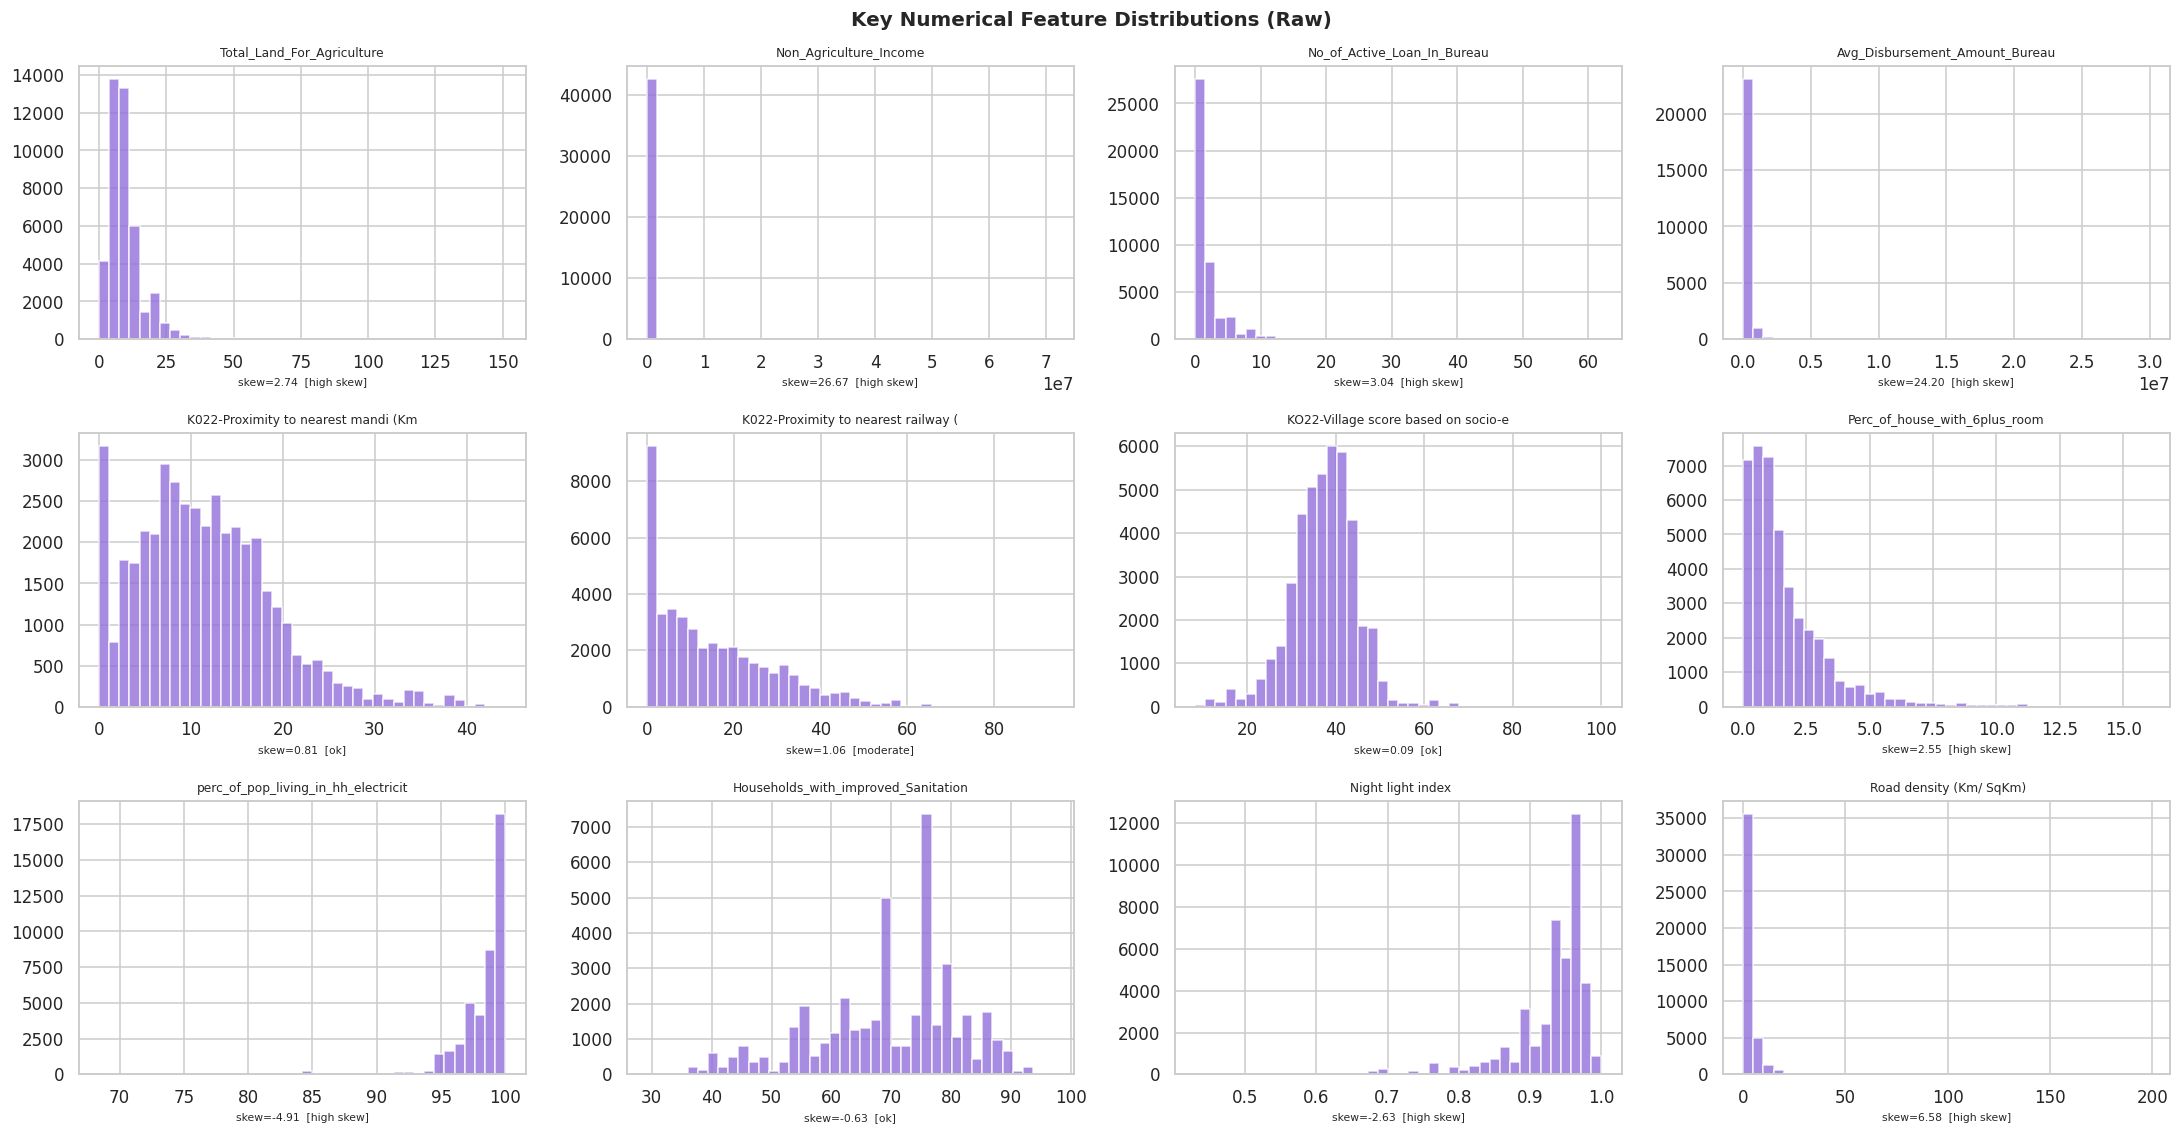

,Feature,Skewness,Missing%
1,Non_Agriculture_Income,26.67,0.0
3,Avg_Disbursement_Amount_Bureau,24.20,43.3
11,Road density (Km/ SqKm),6.58,0.0
8,perc_of_pop_living_in_hh_electricity,-4.91,0.4
2,No_of_Active_Loan_In_Bureau,3.04,0.0
0,Total_Land_For_Agriculture,2.74,0.1
10,Night light index,-2.63,0.0
7,Perc_of_house_with_6plus_room,2.55,0.4
5,K022-Proximity to nearest railway (Km),1.06,0.0
4,K022-Proximity to nearest mandi (Km),0.81,0.0


In [ ]:
KEY_NUM = [
    'Total_Land_For_Agriculture',
    'Non_Agriculture_Income',
    'No_of_Active_Loan_In_Bureau',
    'Avg_Disbursement_Amount_Bureau',
    'K022-Proximity to nearest mandi (Km)',
    'K022-Proximity to nearest railway (Km)',
    'KO22-Village score based on socio-economic parameters (0 to 100)',
    'Perc_of_house_with_6plus_room',
    'perc_of_pop_living_in_hh_electricity',
    'Households_with_improved_Sanitation_Facility',
    ' Night light index',
    ' Road density (Km/ SqKm)',
]
KEY_NUM = [c for c in KEY_NUM if c in df.columns]

nrows = (len(KEY_NUM) + 3) // 4
fig, axes = plt.subplots(nrows, 4, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(KEY_NUM):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax = axes[i]
    ax.hist(data, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8)
    skew_val = data.skew()
    flag = 'high skew' if abs(skew_val) > 2 else ('moderate' if abs(skew_val) > 1 else 'ok')
    ax.set_title(col[:35], fontsize=8)
    ax.set_xlabel(f'skew={skew_val:.2f}  [{flag}]', fontsize=7)

for j in range(len(KEY_NUM), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numerical Feature Distributions (Raw)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

skew_summary = []
for col in KEY_NUM:
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    skew_summary.append({
        'Feature': col[:50],
        'Skewness': round(data.skew(), 2),
        'Missing%': round(df[col].isnull().mean() * 100, 1)
    })

skew_df = pd.DataFrame(skew_summary).sort_values('Skewness', key=abs, ascending=False)
skew_df

**Insight:** Land size, loan disbursement, and non-agricultural income are all heavily right-skewed. Tree-based models handle this natively, but linear models will need these features log-transformed.

### 3.2 Correlation with Target

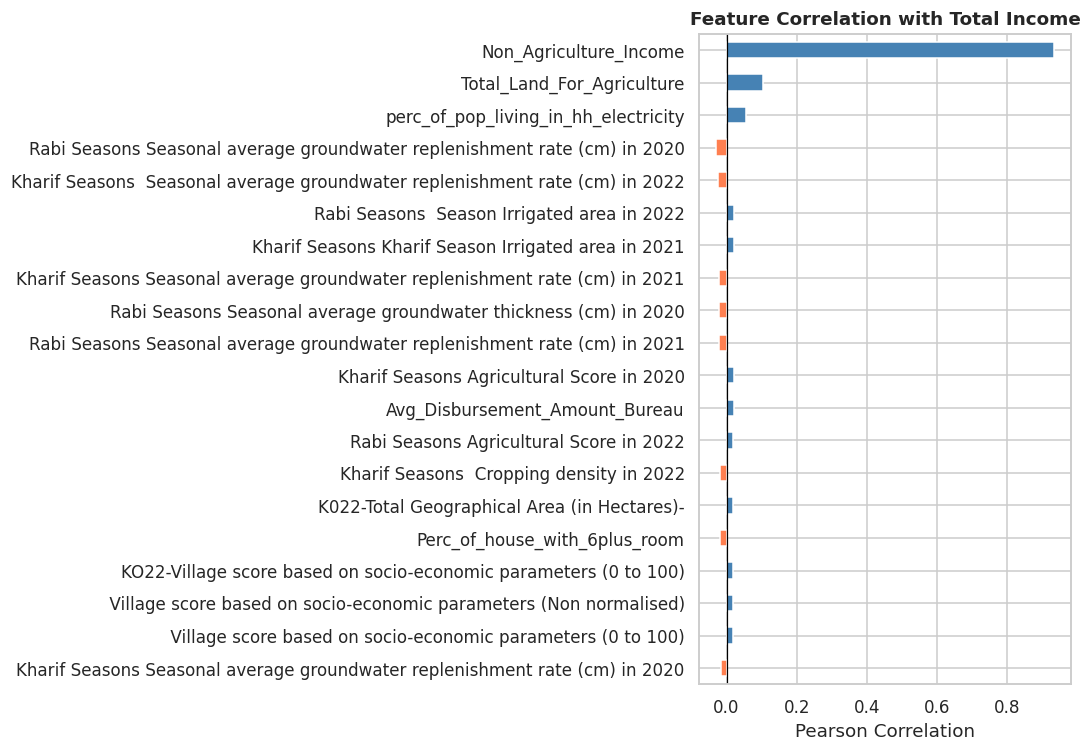

Top 20 correlated features:
Non_Agriculture_Income                                                          0.933920
Total_Land_For_Agriculture                                                      0.105082
perc_of_pop_living_in_hh_electricity                                            0.054039
Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020      -0.029615
Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022   -0.024658
Rabi Seasons  Season Irrigated area in 2022                                     0.022281
Kharif Seasons Kharif Season Irrigated area in 2021                             0.022281
Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021    -0.021831
Rabi Seasons Seasonal average groundwater thickness (cm) in 2020               -0.021744
Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021      -0.020755
Kharif Seasons Agricultural Score in 2020                                       0.

In [ ]:
all_num = df.select_dtypes(include='number').columns.drop(['FarmerID', 'Zipcode'], errors='ignore').tolist()
corr_target = df[all_num].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_corr = corr_target.head(20)
colors = ['steelblue' if v > 0 else 'coral' for v in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Total Income', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 20 correlated features:')
print(corr_target.head(20).to_string())

**Insight:** Non-agricultural income and land size are the strongest individual predictors. Village-level scores (agri quality, night light, socio-economic) add useful signal. Mandi distance is negatively correlated — farmers further from markets tend to earn less, which makes intuitive sense.

### 3.3 Correlation Heatmap (Top Predictors)

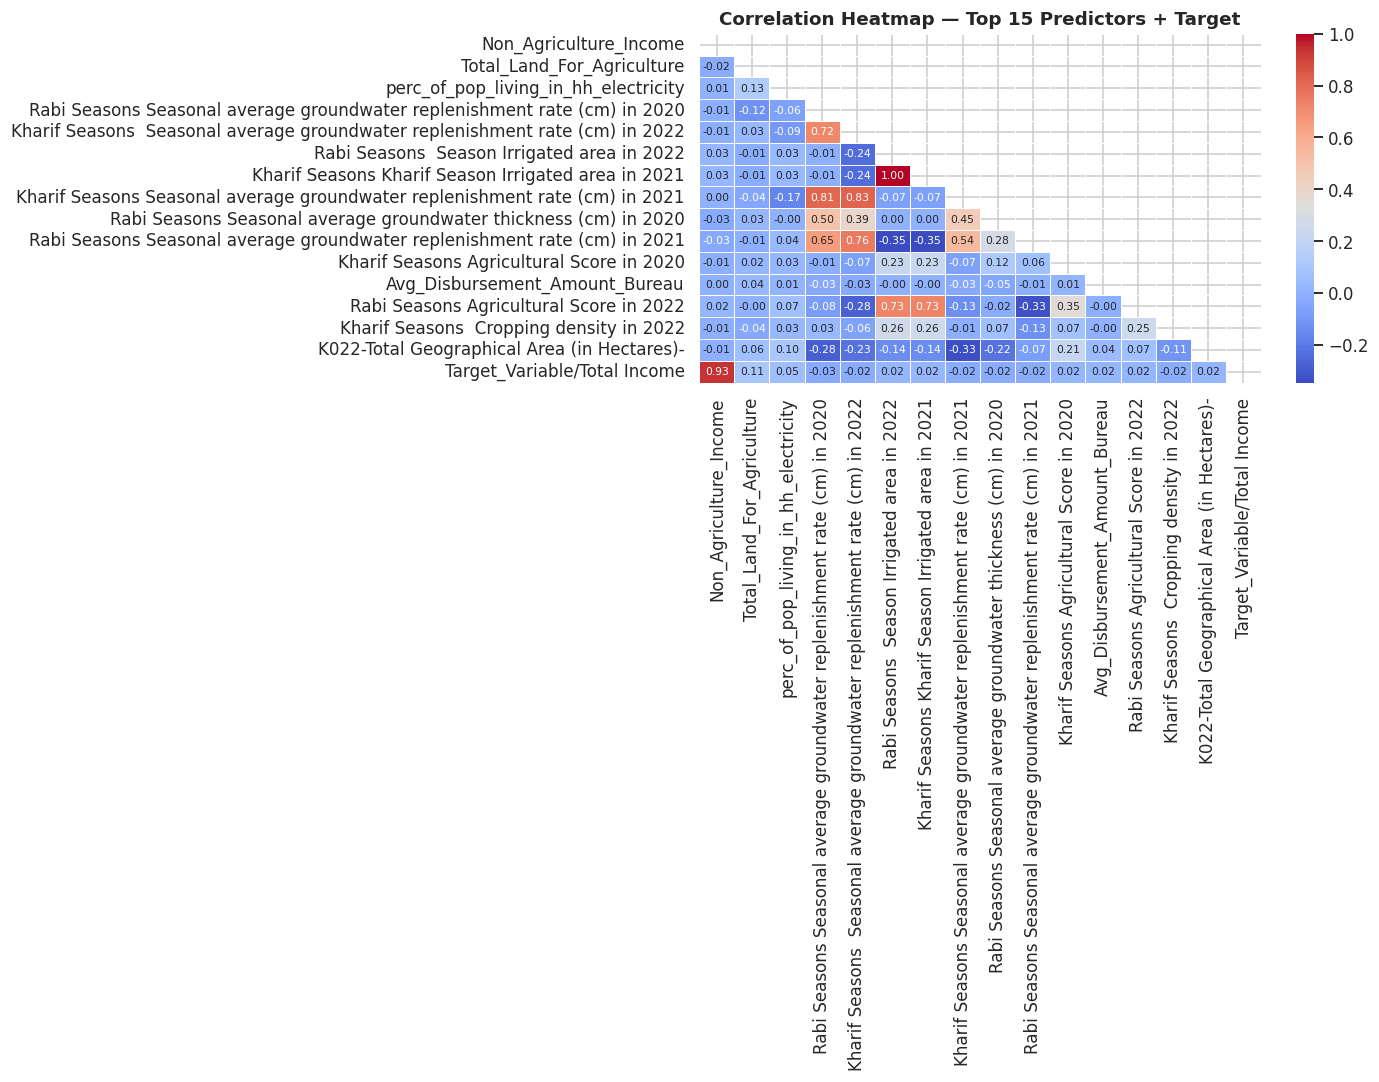

High inter-feature correlations (>0.80):
  Rabi Seasons Seasonal average  vs Kharif Seasons Seasonal averag: 0.81
  Kharif Seasons  Seasonal avera vs Kharif Seasons Seasonal averag: 0.83
  Rabi Seasons  Season Irrigated vs Kharif Seasons Kharif Season I: 1.0


In [ ]:
top_feats = corr_target.head(15).index.tolist() + [TARGET]
corr_mat = df[top_feats].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Top 15 Predictors + Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

corr_pred = corr_mat.drop(TARGET, axis=0).drop(TARGET, axis=1)
high_corr_pairs = []
for i in range(len(corr_pred.columns)):
    for j in range(i+1, len(corr_pred.columns)):
        val = abs(corr_pred.iloc[i, j])
        if val > 0.80:
            high_corr_pairs.append((corr_pred.columns[i][:30], corr_pred.columns[j][:30], round(val, 2)))

if high_corr_pairs:
    print('High inter-feature correlations (>0.80):')
    for a, b, v in high_corr_pairs:
        print(f'  {a} vs {b}: {v}')
else:
    print('No multicollinearity issues found (all pairs < 0.80).')

**Insight:** Where features are highly correlated with each other (>0.80), Ridge regression will handle it fine. For linear models, consider dropping one from each highly collinear pair. Tree models are unaffected.

### 3.4 Scatter Plots — Key Predictors vs Income

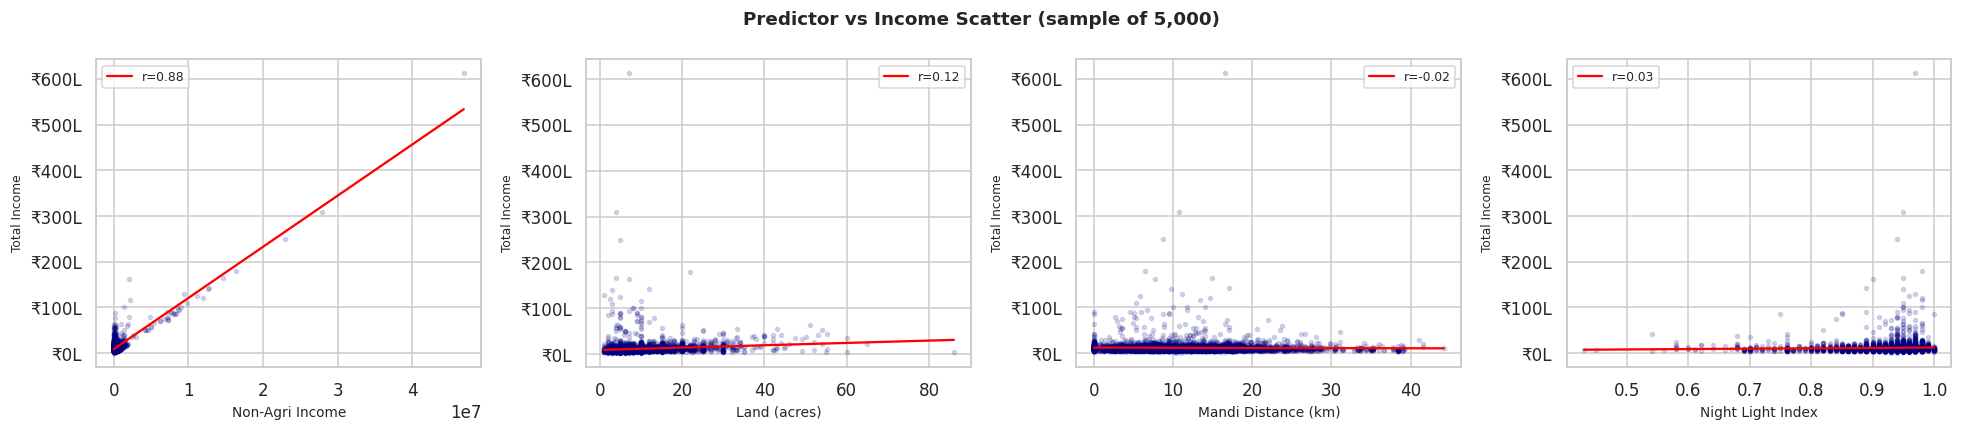

In [ ]:
SCATTER_FEATS = [
    ('Non_Agriculture_Income', 'Non-Agri Income'),
    ('Total_Land_For_Agriculture', 'Land (acres)'),
    ('K022-Proximity to nearest mandi (Km)', 'Mandi Distance (km)'),
    (' Night light index', 'Night Light Index'),
]
SCATTER_FEATS = [(c, l) for c, l in SCATTER_FEATS if c in df.columns]

sample = df.sample(min(5000, len(df)))
fig, axes = plt.subplots(1, len(SCATTER_FEATS), figsize=(18, 4))

for ax, (col, label) in zip(axes, SCATTER_FEATS):
    x = pd.to_numeric(sample[col], errors='coerce')
    y = sample[TARGET]
    valid = pd.DataFrame({'x': x, 'y': y}).dropna()
    ax.scatter(valid['x'], valid['y'], alpha=0.15, s=7, color='navy')
    m, b, r, *_ = stats.linregress(valid['x'], valid['y'])
    xs = np.linspace(valid['x'].min(), valid['x'].max(), 100)
    ax.plot(xs, m*xs + b, color='red', linewidth=1.5, label=f'r={r:.2f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Total Income', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
    ax.legend(fontsize=8)

plt.suptitle('Predictor vs Income Scatter (sample of 5,000)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis
### 4.1 State & Region

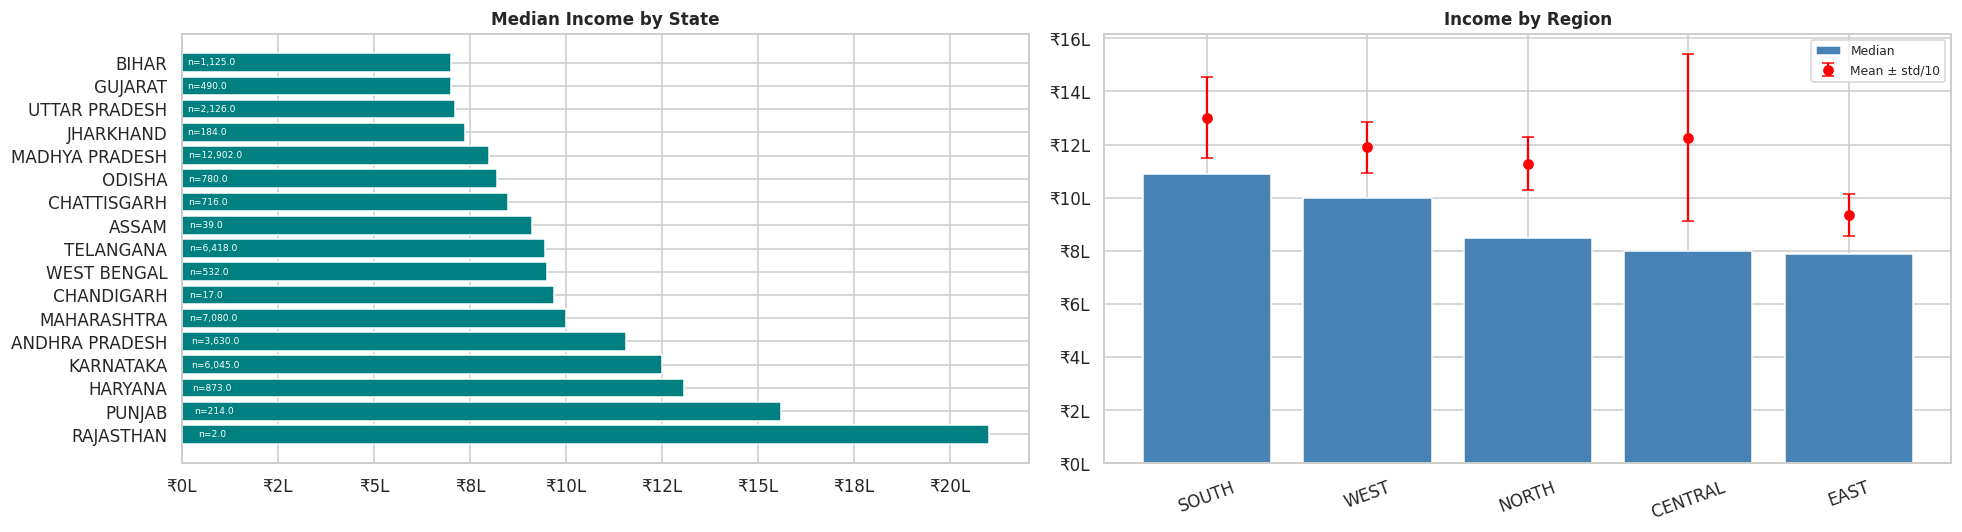

,Median_Income,Count
State,,
RAJASTHAN,2100000.0,2
PUNJAB,1559375.0,214
HARYANA,1305875.0,873
KARNATAKA,1250000.0,6045
ANDHRA PRADESH,1156000.0,3630
MAHARASHTRA,1000000.0,7080
CHANDIGARH,967500.0,17
WEST BENGAL,950000.0,532
TELANGANA,945000.0,6418


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

state_stats = df.groupby('State').agg(
    Median_Income=(TARGET, 'median'),
    Count=('FarmerID', 'count')
).sort_values('Median_Income', ascending=False)

bars = axes[0].barh(state_stats.index, state_stats['Median_Income'], color='teal')
axes[0].set_title('Median Income by State', fontsize=11, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
for bar, (_, row) in zip(bars, state_stats.iterrows()):
    axes[0].text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                 f'n={row.Count:,}', va='center', fontsize=6, color='white')

region_stats = df.groupby('REGION')[TARGET].agg(['median', 'mean', 'std']).sort_values('median', ascending=False)
x = range(len(region_stats))
axes[1].bar(x, region_stats['median'], color='steelblue', label='Median')
axes[1].errorbar(x, region_stats['mean'], yerr=region_stats['std']/10,
                 fmt='o', color='red', capsize=4, label='Mean ± std/10')
axes[1].set_xticks(x)
axes[1].set_xticklabels(region_stats.index, rotation=20)
axes[1].set_title('Income by Region', fontsize=11, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

state_stats

**Insight:** Median income varies 2–3× across states, making State and Region strong predictors. District has 400+ unique values — use target encoding instead of one-hot to avoid dimensionality explosion.

### 4.2 Gender, Marital Status & Ownership

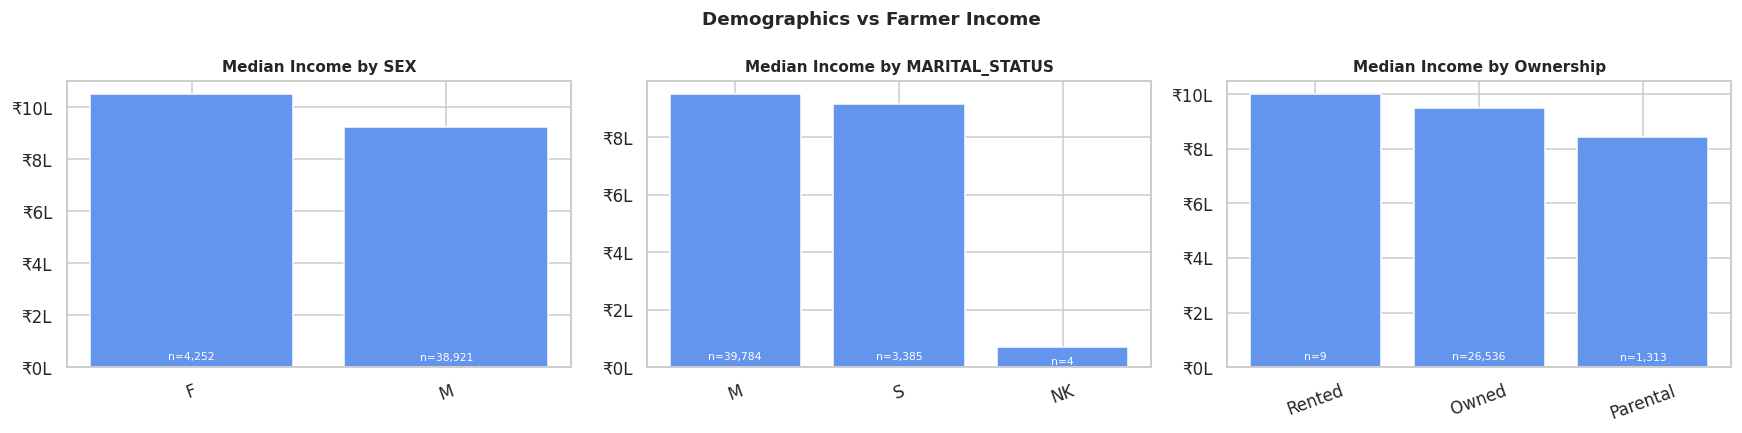

SEX:
SEX
M    38921
F     4252

MARITAL_STATUS:
MARITAL_STATUS
M     39784
S      3385
NK        4



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['SEX', 'MARITAL_STATUS', 'Ownership']):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    grp = df.groupby(col)[TARGET].median().sort_values(ascending=False)
    counts = df[col].value_counts()
    ax.bar(grp.index, grp.values, color='cornflowerblue')
    ax.set_title(f'Median Income by {col}', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(grp.index):
        ax.text(i, grp[v] * 0.02, f'n={counts.get(v, 0):,}',
                ha='center', fontsize=7, color='white', va='bottom')

plt.suptitle('Demographics vs Farmer Income', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for col in ['SEX', 'MARITAL_STATUS']:
    if col in df.columns:
        print(f'{col}:')
        print(df[col].value_counts().to_string())
        print()

**Insight:** A gender income gap exists but is modest — it's likely tied to land ownership patterns rather than gender alone. Marital status shows slight variation. Both are low-cardinality and can be binary encoded.

### 4.3 Village Agricultural & Socio-Economic Category

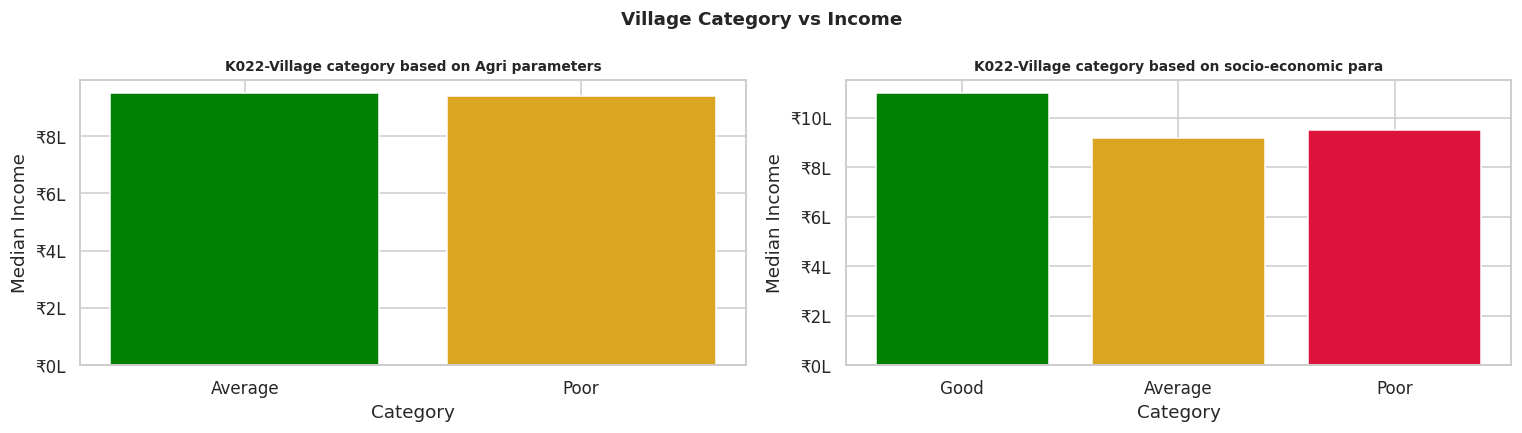

K022-Village category based on Agri parameters (Good, Average, Poor)
Poor       32848
Average    10325


In [ ]:
agri_cat  = 'K022-Village category based on Agri parameters (Good, Average, Poor)'
socio_cat = 'K022-Village category based on socio-economic parameters (Good, Average, Poor)'
cat_cols_to_plot = [(c, c.split('(')[0].strip()) for c in [agri_cat, socio_cat] if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols_to_plot), figsize=(14, 4))
if len(cat_cols_to_plot) == 1:
    axes = [axes]

order = ['Good', 'Average', 'Poor']
for ax, (col, label) in zip(axes, cat_cols_to_plot):
    grp = df.groupby(col)[TARGET].median()
    present_order = [v for v in order if v in grp.index]
    grp = grp.reindex(present_order)
    colors = ['green', 'goldenrod', 'crimson'][:len(present_order)]
    ax.bar(grp.index, grp.values, color=colors)
    ax.set_title(label[:50], fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
    ax.set_xlabel('Category')
    ax.set_ylabel('Median Income')

plt.suptitle('Village Category vs Income', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

if agri_cat in df.columns:
    print(df[agri_cat].value_counts().to_string())

**Insight:** Farmers in "Good" agri-category villages earn significantly more. This is a strong predictor. Encode ordinally in Phase 2: Good=2, Average=1, Poor=0.

## 5. Seasonal & Temporal Analysis (Kharif / Rabi across 2020–2022)
### 5.1 Rainfall Patterns across Seasons

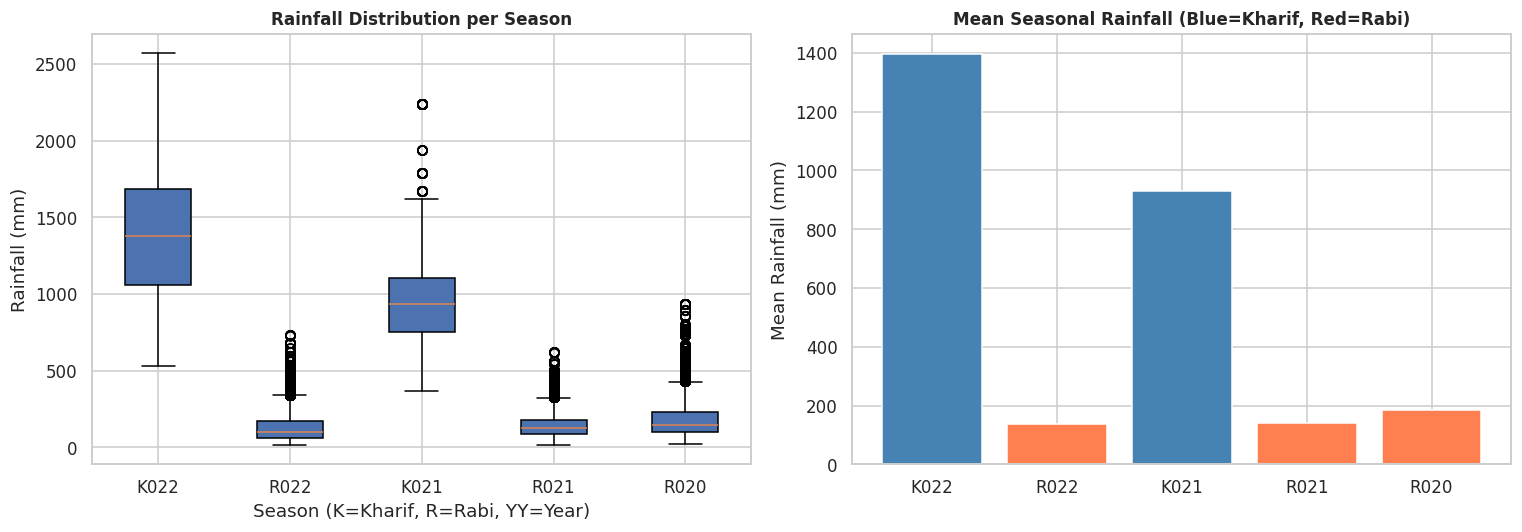

K022: 1394.8 mm
R022: 138.9 mm
K021: 930.9 mm
R021: 141.3 mm
R020: 184.1 mm


In [ ]:
rain_map = {
    'K022': 'K022-Seasonal Average Rainfall (mm)',
    'R022': 'R022-Seasonal Average Rainfall (mm)',
    'K021': 'K021-Seasonal Average Rainfall (mm)',
    'R021': 'R021-Seasonal Average Rainfall (mm)',
    'R020': 'R020-Seasonal Average Rainfall (mm)',
}
rain_map = {k: v for k, v in rain_map.items() if v in df.columns}
rain_data = {k: pd.to_numeric(df[v], errors='coerce').dropna() for k, v in rain_map.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(rain_data.values(), labels=rain_data.keys(), patch_artist=True)
axes[0].set_title('Rainfall Distribution per Season', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_xlabel('Season (K=Kharif, R=Rabi, YY=Year)')

rain_means = {k: v.mean() for k, v in rain_data.items()}
colors_bar = ['steelblue' if 'K' in k else 'coral' for k in rain_means.keys()]
axes[1].bar(rain_means.keys(), rain_means.values(), color=colors_bar)
axes[1].set_title('Mean Seasonal Rainfall (Blue=Kharif, Red=Rabi)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Rainfall (mm)')

plt.tight_layout()
plt.show()

for k, v in rain_means.items():
    print(f'{k}: {v:.1f} mm')

**Insight:** Kharif (monsoon) seasons have higher and more variable rainfall than Rabi (winter). Year-over-year rainfall changes can capture climate shocks that affect crop yield. Consider engineering features like `rain_yoy_delta` and rainfall coefficient of variation.

### 5.2 Agriculture Score Trends across Seasons

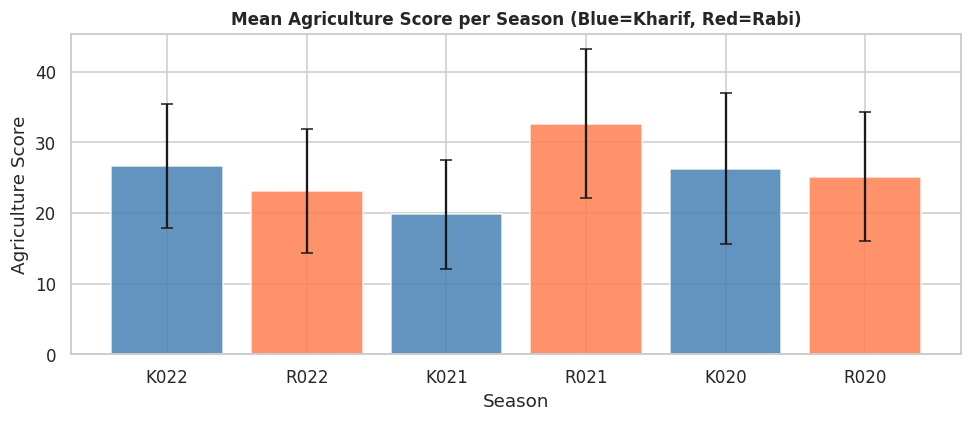

K022: 26.64 ± 8.73
R022: 23.08 ± 8.81
K021: 19.84 ± 7.72
R021: 32.65 ± 10.56
K020: 26.27 ± 10.66
R020: 25.17 ± 9.08

Agricultural performance columns found: 6
       Kharif Seasons  Agricultural performance in 2022  Rabi Seasons Agricultural performance in 2022  Rabi Seasons Agricultural performance in 2021
count                                          43173.00                                       43173.00                                       43173.00
mean                                              24.67                                          20.82                                          22.21
std                                               12.85                                          11.84                                          11.23
min                                                0.00                                           0.00                                           0.00
25%                                               14.03                                    

In [ ]:
agri_score_map = {
    'K022': 'Kharif Seasons  Agricultural Score in 2022',
    'R022': 'Rabi Seasons Agricultural Score in 2022',
    'K021': 'Kharif Seasons Agricultural Score in 2021',
    'R021': 'Rabi Seasons Agricultural Score in 2021',
    'K020': 'Kharif Seasons Agricultural Score in 2020',
    'R020': 'Rabi Seasons Agricultural Score in 2020',
}
agri_score_map = {k: v for k, v in agri_score_map.items() if v in df.columns}

if agri_score_map:
    score_means = {k: pd.to_numeric(df[v], errors='coerce').mean() for k, v in agri_score_map.items()}
    score_stds  = {k: pd.to_numeric(df[v], errors='coerce').std()  for k, v in agri_score_map.items()}

    keys   = list(score_means.keys())
    means  = list(score_means.values())
    stds   = list(score_stds.values())
    colors = ['steelblue' if 'K' in k else 'coral' for k in keys]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(keys, means, color=colors, yerr=stds, capsize=4, alpha=0.85)
    ax.set_title('Mean Agriculture Score per Season (Blue=Kharif, Red=Rabi)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Agriculture Score')
    ax.set_xlabel('Season')
    plt.tight_layout()
    plt.show()

    for k in keys:
        print(f'{k}: {score_means[k]:.2f} ± {score_stds[k]:.2f}')

perf_cols = [c for c in df.columns if 'Agricultural performance' in c]
if perf_cols:
    print(f'\nAgricultural performance columns found: {len(perf_cols)}')
    print(df[perf_cols[:3]].describe().round(2).to_string())

**Insight:** Agriculture scores vary widely across seasons (high standard deviation). Farmers with consistently high scores over the years tend to earn more. Useful features to engineer: `agri_score_mean`, `agri_score_std` (volatility), and `agri_score_trend`.

### 5.3 Wide-Format Seasonal Columns — Structure Overview

In [ ]:
kharif_cols = [c for c in df.columns if 'Kharif' in c]
rabi_cols   = [c for c in df.columns if 'Rabi' in c]

print(f'Kharif-related columns : {len(kharif_cols)}')
print(f'Rabi-related columns   : {len(rabi_cols)}')
print()
print('Kharif columns:')
for c in kharif_cols:
    print(f'  {c}')

Kharif-related columns : 29
Rabi-related columns   : 27

Kharif columns:
  Kharif Seasons  Irrigated area in 2022
  Kharif Seasons  Cropping density in 2022
  Kharif Seasons  Agricultural performance in 2022
  Kharif Seasons  Agricultural Score in 2022
  Kharif Seasons  Type of soil in 2022
  Kharif Seasons  Type of water bodies in hectares 2022
  Kharif Seasons  Agro Ecological Sub Zone in 2022
  Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022
  Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022
  Rabi Seasons Kharif Season Irrigated area in 2021
  Kharif Seasons Kharif Season Irrigated area in 2021
  Kharif Seasons Cropping density in 2021
  Kharif Seasons Agricultural performance in 2021
  Kharif Seasons Agricultural Score in 2021
  Kharif Seasons Type of soil in 2021
  Kharif Seasons Type of water bodies in hectares 2021
  Kharif Seasons Agro Ecological Sub Zone in 2021
  Kharif Seasons Seasonal average groundwater thickness (cm) in 202

**Insight:** The data is in wide format — each farmer has separate Kharif and Rabi columns for 2020–2022. Rather than just averaging these, consider computing year-over-year deltas (K022 - K021) as climate shock indicators, across-season standard deviation as a volatility score, and a Kharif vs Rabi income split ratio.

## 6. Spatial & Living Standards Analysis
### 6.1 Night Light & Road Density vs Income

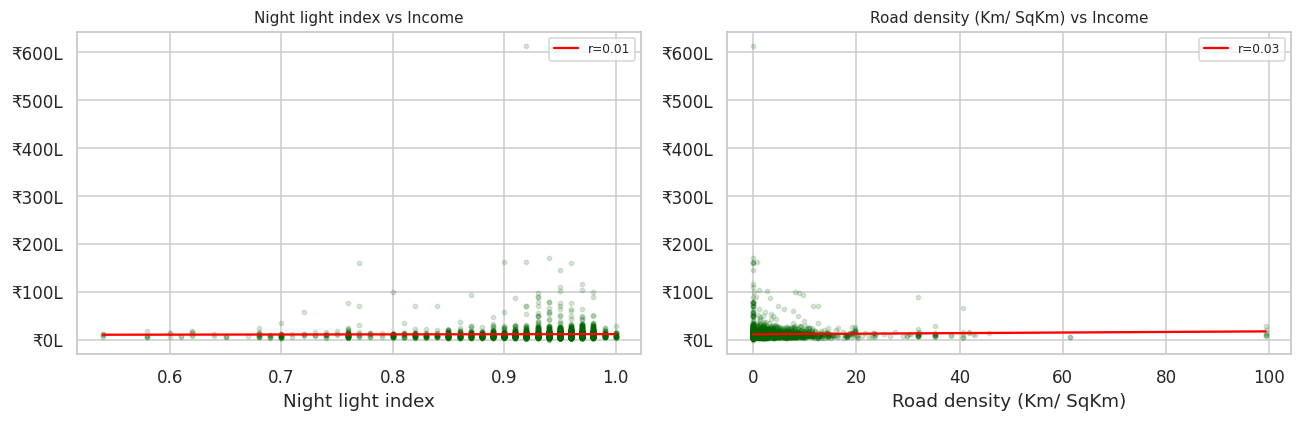

In [ ]:
night_col = ' Night light index'
road_col  = ' Road density (Km/ SqKm)'
spatial_cols = [(c, c.strip()) for c in [night_col, road_col] if c in df.columns]

sample = df.sample(min(4000, len(df)))

if spatial_cols:
    fig, axes = plt.subplots(1, len(spatial_cols), figsize=(12, 4))
    if len(spatial_cols) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, spatial_cols):
        x = pd.to_numeric(sample[col], errors='coerce')
        y = sample[TARGET]
        valid = pd.DataFrame({'x': x, 'y': y}).dropna()
        ax.scatter(valid['x'], valid['y'], alpha=0.15, s=8, color='darkgreen')
        m, b, r, *_ = stats.linregress(valid['x'], valid['y'])
        xs = np.linspace(valid['x'].min(), valid['x'].max(), 100)
        ax.plot(xs, m*xs + b, color='red', linewidth=1.5, label=f'r={r:.2f}')
        ax.set_title(f'{label} vs Income', fontsize=10)
        ax.set_xlabel(label)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

**Insight:** Night light index is a satellite proxy for economic activity — brighter villages tend to have more commerce and higher farmer incomes. Road density captures infrastructure quality. Both are area-level features that likely interact with individual land size.

### 6.2 Living Standards Composite

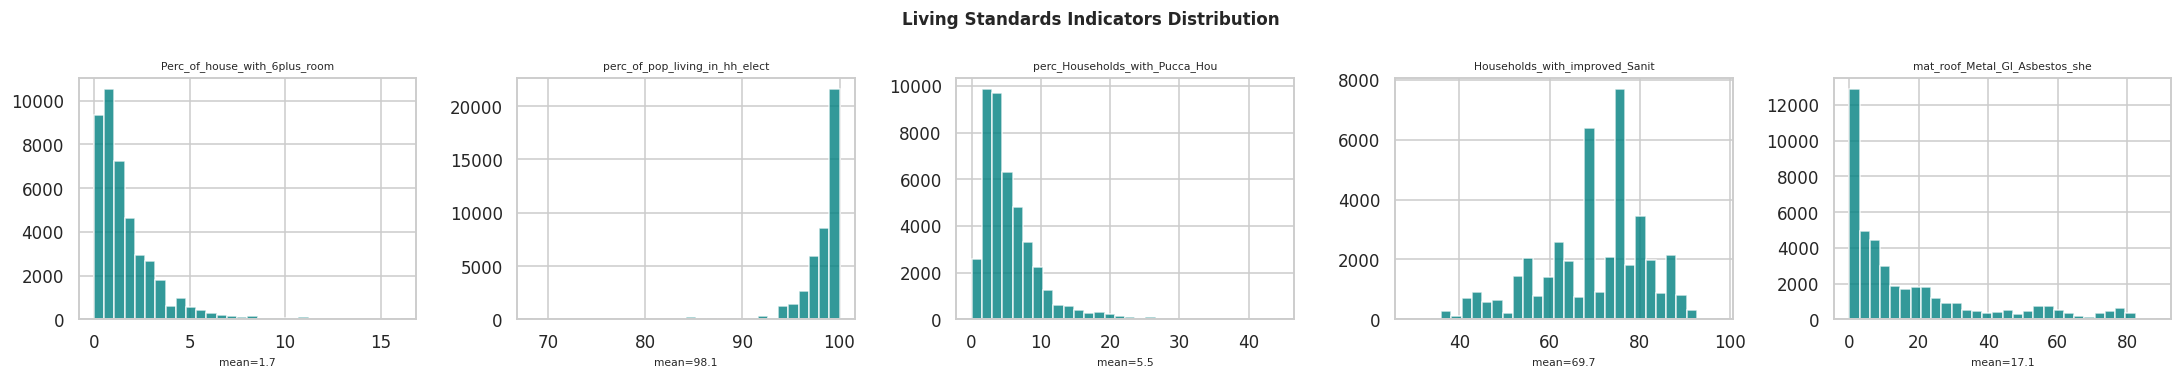

Correlation with Total Income:
  Perc_of_house_with_6plus_room                : r=-0.019  p=0.0001
  perc_of_pop_living_in_hh_electricity         : r=0.025  p=0.0000
  perc_Households_with_Pucca_House_That_Has_Mor: r=-0.009  p=0.0674
  Households_with_improved_Sanitation_Facility : r=0.005  p=0.3049
  mat_roof_Metal_GI_Asbestos_sheets            : r=-0.001  p=0.8412


In [ ]:
living_cols = [
    'Perc_of_house_with_6plus_room',
    'perc_of_pop_living_in_hh_electricity',
    'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
    'Households_with_improved_Sanitation_Facility',
    'mat_roof_Metal_GI_Asbestos_sheets',
]
living_cols = [c for c in living_cols if c in df.columns]

fig, axes = plt.subplots(1, len(living_cols), figsize=(20, 3.5))
for ax, col in zip(axes, living_cols):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(data, bins=30, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(col[:30], fontsize=7)
    ax.set_xlabel(f'mean={data.mean():.1f}', fontsize=7)

plt.suptitle('Living Standards Indicators Distribution', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with Total Income:')
for col in living_cols:
    r, p = stats.pearsonr(
        pd.to_numeric(df[col], errors='coerce').fillna(0),
        df[TARGET]
    )
    print(f'  {col[:45]:45s}: r={r:.3f}  p={p:.4f}')

**Insight:** Living standard indicators are moderately correlated with income. Since they measure similar things, combining them into a single `living_standard_index` (mean of all) would reduce noise and simplify the model.

## 7. EDA Summary — Key Findings for Phase 2


| Finding | Phase 2 Action |
|---|---|
| Target is heavily right-skewed (skew > 5) | Train on `log1p(income)`, predict then `expm1()` |
| `Avg_Disbursement_Amount_Bureau`: 43% missing | Impute with 0 + add binary flag `has_bureau_record` |
| `Location/Address type/Ownership`: 35% missing | Impute mode or drop (check feature importance) |
| Temperature stored as `"24.63 /31.27"` strings | Parse into `temp_min`, `temp_max` numeric columns |
| 2 fully duplicate rows, 14 duplicate FarmerIDs | Drop exact duplicates; investigate ID duplicates |
| State/Region: strong predictors, high cardinality | Target encode |
| Ordinal categories: Good / Average / Poor | Ordinal encode (Good=2, Average=1, Poor=0) |
| Seasonal columns in wide format (K022, R022…) | Compute deltas, std, CV — do NOT just average |
| Night light × land: interaction effect | Engineer `nightlight_x_land` feature |
| Living standard metrics all correlated | Composite index: `living_standard_index` |


#phase 2

#data cleaning and processing

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/train_data_1.csv")

df.head()
df.shape

(43173, 105)

In [ ]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43173 entries, 0 to 43172
Columns: 105 entries, FarmerID to Target_Variable/Total Income
dtypes: float64(62), int64(5), object(38)
memory usage: 34.6+ MB


,0
Avg_Disbursement_Amount_Bureau,18706
Address type,15315
Ownership,15315
Location,15315
mat_roof_Metal_GI_Asbestos_sheets,154
...,...
Village score based on socio-economic parameters (0 to 100),0
"Village category based on socio-economic parameters (Good, Average, Poor)",0
Land Holding Index source (Total Agri Area/ no of people),0
Road density (Km/ SqKm),0


In [ ]:
df.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'Location',
       ...
       'Rabi Seasons Agro Ecological Sub Zone in 2020',
       'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020',
       'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020',
       ' Night light index',
       ' Village score based on socio-economic parameters (Non normalised)',
       ' Village score based on socio-economic parameters (0 to 100)',
       ' Village category based on socio-economic parameters (Good, Average, Poor)',
       ' Land Holding Index source (Total Agri Area/ no of people)',
       ' Road density (Km/ SqKm)', 'Target_Variable/Total Income'],
      dtype='object', length=105)

In [ ]:
# location of farmers is not changing so distance is same across all seasons
df.rename(columns={'K022-Nearest Mandi Name': 'nearest mandi name','K022-Proximity to nearest mandi (Km)':'mandi distance',
                   'K022-Proximity to nearest railway (Km)':'nearest railway distance',}, inplace=True)

In [ ]:
df

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,2011619838654310,MADHYA PRADESH,CENTRAL,M,KURWAI,464337,VIDISHA,Aurangpur,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,99.14,23.01,0.89,21.21,31.63,Poor,0.27,0.00,810000
43169,6069817994550520,ODISHA,EAST,M,MANGALPUR,755036,JAJAPUR,Dattapur,M,"20.7305917,86.4006167",...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,96.31,22.65,0.95,26.94,40.91,Poor,0.46,2.81,780000
43170,1670777866848000,ANDHRA PRADESH,SOUTH,M,VATSAVAI,521178,KRISHNA,Bheemavaram,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,74.06,17.18,0.98,23.52,35.37,Poor,0.09,0.00,700000
43171,7825441475417380,MADHYA PRADESH,CENTRAL,M,GUNA,473105,GUNA,Ajronda,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,80.14,22.51,0.93,22.12,33.11,Poor,0.62,0.00,800000


In [ ]:
#soil type is const accross all years , except kharif2020 that we think is data collection error  so we are using r021 data for ll the seasons
df.rename(columns={'Rabi Seasons Type of soil in 2021': 'soil type','Rabi Seasons Type of water bodies in hectares 2021':'water bodies','Rabi Seasons Agro Ecological Sub Zone in 2021':'socio ecological zone',}, inplace=True)

In [ ]:
df

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,2011619838654310,MADHYA PRADESH,CENTRAL,M,KURWAI,464337,VIDISHA,Aurangpur,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,99.14,23.01,0.89,21.21,31.63,Poor,0.27,0.00,810000
43169,6069817994550520,ODISHA,EAST,M,MANGALPUR,755036,JAJAPUR,Dattapur,M,"20.7305917,86.4006167",...,DECCAN PLATU HOT SEMI-ARID ECO-REGION,96.31,22.65,0.95,26.94,40.91,Poor,0.46,2.81,780000
43170,1670777866848000,ANDHRA PRADESH,SOUTH,M,VATSAVAI,521178,KRISHNA,Bheemavaram,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,74.06,17.18,0.98,23.52,35.37,Poor,0.09,0.00,700000
43171,7825441475417380,MADHYA PRADESH,CENTRAL,M,GUNA,473105,GUNA,Ajronda,M,NaN,...,CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,80.14,22.51,0.93,22.12,33.11,Poor,0.62,0.00,800000


In [ ]:
columns_to_drop = [
    'Rabi Seasons Type of soil in 2020',
    'Rabi Seasons Type of soil in 2022',
    'Kharif Seasons Type of soil in 2020',
    'Kharif Seasons Type of soil in 2021',
    'Kharif Seasons  Type of soil in 2022',
    'Kharif Seasons Agro Ecological Sub Zone in 2020',
    'Kharif Seasons Agro Ecological Sub Zone in 2021',
    'Kharif Seasons  Agro Ecological Sub Zone in 2022',
    'Rabi Seasons Agro Ecological Sub Zone in 2020',
    'Rabi Seasons Agro Ecological Sub Zone in 2022',
    'Rabi Seasons Type of water bodies in hectares 2020',
    'Rabi Seasons Type of water bodies in hectares 2022',
    'Kharif Seasons Type of water bodies in hectares 2020',
    'Kharif Seasons Type of water bodies in hectares 2021',
    'Kharif Seasons  Type of water bodies in hectares 2022',
    'KO22-Village score based on socio-economic parameters (0 to 100)',
    'K022-Village category based on socio-economic parameters (Good, Average, Poor)'

]

# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Report columns that were not found
non_existing_columns = [col for col in columns_to_drop if col not in df.columns]
if non_existing_columns:
    print(f"Warning: The following columns were not found in the DataFrame and were therefore not dropped: {non_existing_columns}")

# Drop only the existing columns
df = df.drop(columns=existing_columns_to_drop)

In [ ]:
df

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agricultural Score in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,33.88,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,14.04,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,25.90,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,11.98,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,25.66,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,2011619838654310,MADHYA PRADESH,CENTRAL,M,KURWAI,464337,VIDISHA,Aurangpur,M,NaN,...,24.84,99.14,23.01,0.89,21.21,31.63,Poor,0.27,0.00,810000
43169,6069817994550520,ODISHA,EAST,M,MANGALPUR,755036,JAJAPUR,Dattapur,M,"20.7305917,86.4006167",...,28.98,96.31,22.65,0.95,26.94,40.91,Poor,0.46,2.81,780000
43170,1670777866848000,ANDHRA PRADESH,SOUTH,M,VATSAVAI,521178,KRISHNA,Bheemavaram,M,NaN,...,27.72,74.06,17.18,0.98,23.52,35.37,Poor,0.09,0.00,700000
43171,7825441475417380,MADHYA PRADESH,CENTRAL,M,GUNA,473105,GUNA,Ajronda,M,NaN,...,18.37,80.14,22.51,0.93,22.12,33.11,Poor,0.62,0.00,800000


In [ ]:
df.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'Location', 'Address type', 'Ownership',
       'No_of_Active_Loan_In_Bureau', 'Avg_Disbursement_Amount_Bureau',
       'Non_Agriculture_Income', 'Total_Land_For_Agriculture',
       'K022-Village category based on Agri parameters (Good, Average, Poor)',
       'nearest mandi name', 'mandi distance', 'nearest railway distance',
       'K022-Seasonal Average Rainfall (mm)',
       'K022-Ambient temperature (min & max)',
       'R022-Village category based on Agri parameters (Good, Average, Poor)',
       'R022-Seasonal Average Rainfall (mm)',
       'R022-Ambient temperature (min & max)',
       'K021-Seasonal Average Rainfall (mm)',
       'K021-Ambient temperature (min & max)',
       'R021-Seasonal Average Rainfall (mm)',
       'R021-Ambient temperature (min & max)',
       'R020-Seasonal Average Rainfall (mm)',
       'R020-Ambient temperature (min & max)', 'Perc_of_house

In [ ]:
#column renaming for better understanding and simplicity
df.rename(columns={'Kharif Seasons  Irrigated area in 2022': 'k022-irrigated area',
                   'Kharif Seasons Kharif Season Irrigated area in 2021':'k021-irrigated area',
                   'Kharif Seasons Kharif Season Irrigated area in 2020':'k020-irrigated area',
                   'Rabi Seasons Kharif Season Irrigated area in 2021':'r021-irrigated area',
                   'Rabi Seasons Kharif Season Irrigated area in 2020':'r020-irrigated area',
                   'Rabi Seasons  Season Irrigated area in 2022':'r022-irrigated area',
                   'Rabi Seasons Cropping density in 2020':'r020-cropping density',
                   'Rabi Seasons Cropping density in 2021':'r021-cropping density',
                   'Rabi Seasons Cropping density in 2022':'r022-cropping density',
                   'Rabi Seasons Agricultural performance in 2020':'r020-agriculture performance',
                   'Rabi Seasons Agricultural performance in 2021':'r021-agriculture performance',
                    'Rabi Seasons Agricultural performance in 2022':'r022-agriculture performance',
                   'Rabi Seasons Agricultural Score in 2020':'r020-agriculture score',
                   'Rabi Seasons Agricultural Score in 2021':'r021-agriculture score',
                   'Rabi Seasons Agricultural Score in 2022':'r022-agriculture score',
                   'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020':'r020-avg groundwater thickness',
                   'Rabi Seasons Seasonal average groundwater thickness (cm) in 2021':'r021-avg groundwater thickness',
                    'Rabi Seasons Seasonal average groundwater thickness (cm) in 2022':'r022-avg groundwater thickness',
                   'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020':'r020-average groundwater replenishment rate',
                   'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021':'r021-average groundwater replenishment rate',
                   'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2022':'r022-average groundwater replenishment rate',
                   'Kharif Seasons Cropping density in 2021':'k021-cropping density',
                   'Kharif Seasons Cropping density in 2020':'k020-cropping density',
                   'Kharif Seasons  Cropping density in 2022':'k022-cropping density',
                   'Kharif Seasons Seasonal average groundwater thickness (cm) in 2020':'k020-average groundwater thickness',
                   'Kharif Seasons Seasonal average groundwater thickness (cm) in 2021':'k021-average groundwater thickness',
                   'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020':'k020-average groundwater replenishment rate',
                   'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021':'k021-average groundwater replenishment rate',
                   'Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022':'k022-average groundwater thickness',
                   'Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022':'k022-average groundwater replenishment rate',
                   'Kharif Seasons  Agricultural Score in 2022':'k022-agriculture score',
                   'Kharif Seasons  Agricultural performance in 2022':'k022-agriculture performance',
                   'Kharif Seasons Agricultural performance in 2020':'k020-agriculture performance',
                   'Kharif Seasons Agricultural performance in 2021':'k021-agriculture performance',
                   'Kharif Seasons Agricultural Score in 2020':'k020-agriculture score',
                   'Kharif Seasons Agricultural Score in 2021':'k021-agriculture score',
                   'K022-Total Geographical Area (in Hectares)-':'Total Geographical Area (in Hectares)',
                   'K022-Net Agri area (in Ha)-':'Net Agri area (in Ha)',
                   'K022-Net Agri area (% of total geog area)-':'Net Agri area (% of total geog area)'


                   }, inplace=True)

In [ ]:
df.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'Location', 'Address type', 'Ownership',
       'No_of_Active_Loan_In_Bureau', 'Avg_Disbursement_Amount_Bureau',
       'Non_Agriculture_Income', 'Total_Land_For_Agriculture',
       'K022-Village category based on Agri parameters (Good, Average, Poor)',
       'nearest mandi name', 'mandi distance', 'nearest railway distance',
       'K022-Seasonal Average Rainfall (mm)',
       'K022-Ambient temperature (min & max)',
       'R022-Village category based on Agri parameters (Good, Average, Poor)',
       'R022-Seasonal Average Rainfall (mm)',
       'R022-Ambient temperature (min & max)',
       'K021-Seasonal Average Rainfall (mm)',
       'K021-Ambient temperature (min & max)',
       'R021-Seasonal Average Rainfall (mm)',
       'R021-Ambient temperature (min & max)',
       'R020-Seasonal Average Rainfall (mm)',
       'R020-Ambient temperature (min & max)', 'Perc_of_house

In [ ]:
df.shape
df.describe()

,FarmerID,Zipcode,No_of_Active_Loan_In_Bureau,Avg_Disbursement_Amount_Bureau,Non_Agriculture_Income,Total_Land_For_Agriculture,mandi distance,nearest railway distance,K022-Seasonal Average Rainfall (mm),R022-Seasonal Average Rainfall (mm),...,r020-agriculture performance,r020-agriculture score,r020-avg groundwater thickness,r020-average groundwater replenishment rate,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
count,4.317300e+04,43173.000000,43173.000000,2.446700e+04,4.317300e+04,43110.000000,43173.000000,43173.000000,43173.000000,43173.000000,...,43173.000000,43173.000000,43173.000000,43173.000000,43173.000000,43173.000000,43173.000000,43173.000000,43173.000000,4.317300e+04
mean,5.485131e+15,486793.623955,1.785838,2.431558e+05,2.806885e+05,9.961668,11.511767,15.085419,1394.794459,138.885864,...,23.833570,25.169490,84.635011,21.201571,0.930563,24.755964,37.377297,0.682734,2.851815,1.222379e+06
std,2.600946e+15,119492.552157,2.742399,4.909697e+05,1.697987e+06,6.910116,7.512893,13.984692,423.762917,109.156408,...,12.134258,9.078551,14.769142,7.057136,0.058226,4.615493,7.479911,1.983861,6.164508,2.064511e+06
min,1.000336e+15,122103.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,530.370000,17.490000,...,0.000000,0.000000,22.370000,0.560000,0.430000,6.740000,8.180000,0.000000,0.000000,2.900000e+04
25%,3.210634e+15,445401.000000,0.000000,5.800000e+04,0.000000e+00,5.000000,6.200000,3.400000,1057.190000,63.910000,...,14.650000,18.820000,74.770000,17.410000,0.920000,22.040000,32.980000,0.160000,0.000000,7.200000e+05
50%,5.486402e+15,483119.000000,1.000000,1.295000e+05,1.000000e+05,10.000000,10.700000,11.400000,1375.800000,102.780000,...,23.160000,26.410000,89.120000,20.340000,0.950000,25.000000,37.780000,0.300000,0.470000,9.500000e+05
75%,7.744641e+15,518594.000000,2.000000,2.833318e+05,2.500000e+05,12.000000,16.000000,23.600000,1687.490000,174.730000,...,32.310000,31.520000,95.330000,25.130000,0.970000,27.590000,41.970000,0.580000,3.400000,1.295000e+06
max,9.999402e+15,855113.000000,62.000000,3.000000e+07,7.128230e+07,151.000000,44.200000,93.700000,2569.100000,733.760000,...,67.820000,57.620000,157.700000,56.880000,1.000000,63.400000,100.000000,112.600000,198.550000,8.000000e+07


In [ ]:
df[df.isnull().any(axis=1)]

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,r020-agriculture score,r020-avg groundwater thickness,r020-average groundwater replenishment rate,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,33.88,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,14.04,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,11.98,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,25.66,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000
6,3907207441796310,KARNATAKA,SOUTH,M,KUNIGAL,572126,TUMKUR,Naganahalli,S,NaN,...,31.26,92.53,23.13,0.95,21.97,32.86,Poor,0.33,5.52,1235000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,2011619838654310,MADHYA PRADESH,CENTRAL,M,KURWAI,464337,VIDISHA,Aurangpur,M,NaN,...,24.84,99.14,23.01,0.89,21.21,31.63,Poor,0.27,0.00,810000
43169,6069817994550520,ODISHA,EAST,M,MANGALPUR,755036,JAJAPUR,Dattapur,M,"20.7305917,86.4006167",...,28.98,96.31,22.65,0.95,26.94,40.91,Poor,0.46,2.81,780000
43170,1670777866848000,ANDHRA PRADESH,SOUTH,M,VATSAVAI,521178,KRISHNA,Bheemavaram,M,NaN,...,27.72,74.06,17.18,0.98,23.52,35.37,Poor,0.09,0.00,700000
43171,7825441475417380,MADHYA PRADESH,CENTRAL,M,GUNA,473105,GUNA,Ajronda,M,NaN,...,18.37,80.14,22.51,0.93,22.12,33.11,Poor,0.62,0.00,800000


In [ ]:
df.columns[df.isnull().any()].tolist()

['Location',
 'Address type',
 'Ownership',
 'Avg_Disbursement_Amount_Bureau',
 'Total_Land_For_Agriculture',
 'Perc_of_house_with_6plus_room',
 'Women_15_19_Mothers_or_Pregnant_at_time_of_survey',
 'perc_of_pop_living_in_hh_electricity',
 'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
 'mat_roof_Metal_GI_Asbestos_sheets',
 'perc_of_Wall_material_with_Burnt_brick',
 'Households_with_improved_Sanitation_Facility',
 'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k']

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Avg_Disbursement_Amount_Bureau,18706
Address type,15315
Location,15315
Ownership,15315
perc_of_Wall_material_with_Burnt_brick,154
...,...
Village score based on socio-economic parameters (0 to 100),0
"Village category based on socio-economic parameters (Good, Average, Poor)",0
Land Holding Index source (Total Agri Area/ no of people),0
Road density (Km/ SqKm),0


###here most of the columns with empty/nan values are not of our use in predicting the income , so we will remove those clos

In [ ]:
columns_to_drop_2 = ['Location',
                     'Address type',
                     'Ownership',
                     'Women_15_19_Mothers_or_Pregnant_at_time_of_survey'

                      ]

In [ ]:
# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop_2 if col in df.columns]

# Report columns that were not found
non_existing_columns = [col for col in columns_to_drop_2 if col not in df.columns]
if non_existing_columns:
    print(f"Warning: The following columns were not found in the DataFrame and were therefore not dropped: {non_existing_columns}")

# Drop only the existing columns
df = df.drop(columns=existing_columns_to_drop)

In [ ]:
df.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'No_of_Active_Loan_In_Bureau',
       'Avg_Disbursement_Amount_Bureau', 'Non_Agriculture_Income',
       'Total_Land_For_Agriculture',
       'K022-Village category based on Agri parameters (Good, Average, Poor)',
       'nearest mandi name', 'mandi distance', 'nearest railway distance',
       'K022-Seasonal Average Rainfall (mm)',
       'K022-Ambient temperature (min & max)',
       'R022-Village category based on Agri parameters (Good, Average, Poor)',
       'R022-Seasonal Average Rainfall (mm)',
       'R022-Ambient temperature (min & max)',
       'K021-Seasonal Average Rainfall (mm)',
       'K021-Ambient temperature (min & max)',
       'R021-Seasonal Average Rainfall (mm)',
       'R021-Ambient temperature (min & max)',
       'R020-Seasonal Average Rainfall (mm)',
       'R020-Ambient temperature (min & max)', 'Perc_of_house_with_6plus_room',
       'perc_of_pop_li

In [ ]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

,0
Avg_Disbursement_Amount_Bureau,18706
Perc_of_house_with_6plus_room,154
perc_of_pop_living_in_hh_electricity,154
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,154
mat_roof_Metal_GI_Asbestos_sheets,154
Households_with_improved_Sanitation_Facility,154
perc_of_Wall_material_with_Burnt_brick,154
perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k,154
Total_Land_For_Agriculture,63


In [ ]:
# 0 loan == 0 loan amount
df.loc[df['No_of_Active_Loan_In_Bureau'] == 0, 'Avg_Disbursement_Amount_Bureau'] = 0

In [ ]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

,0
Perc_of_house_with_6plus_room,154
perc_of_pop_living_in_hh_electricity,154
perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms,154
mat_roof_Metal_GI_Asbestos_sheets,154
Households_with_improved_Sanitation_Facility,154
perc_of_Wall_material_with_Burnt_brick,154
perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k,154
Total_Land_For_Agriculture,63


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43173 entries, 0 to 43172
Data columns (total 84 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   FarmerID                                                                    43173 non-null  int64  
 1   State                                                                       43173 non-null  object 
 2   REGION                                                                      43173 non-null  object 
 3   SEX                                                                         43173 non-null  object 
 4   CITY                                                                        43173 non-null  object 
 5   Zipcode                                                                     43173 non-null  int64  
 6   DISTRICT                                      

In [ ]:
cols_with_missing = ['Perc_of_house_with_6plus_room','perc_of_pop_living_in_hh_electricity','perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
                     'mat_roof_Metal_GI_Asbestos_sheets','Households_with_improved_Sanitation_Facility','perc_of_Wall_material_with_Burnt_brick','perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k',
                     'Total_Land_For_Agriculture'
                     ]

In [ ]:
# Interpolate small gaps (up to 3 consecutive hours) linearly
df[cols_with_missing] = df[cols_with_missing].interpolate(method='linear', limit=3)
# For remaining large gaps, use forward fill then backfill
df[cols_with_missing] = df[cols_with_missing].ffill().bfill()

In [ ]:
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

,0


In [ ]:
# df = df.drop_duplicates()
# df = df.sort_values('FarmerID').drop_duplicates('FarmerID', keep='last')
df = df.drop_duplicates()                          # drop fully identical rows first
df = df.drop_duplicates('FarmerID', keep='last')

In [ ]:
def parse_temp(val):
    if pd.isna(val) or '/' not in str(val):
        return np.nan, np.nan
    try:
        parts = str(val).split('/')
        return float(parts[0].strip()), float(parts[1].strip())
    except:
        return np.nan, np.nan

temp_cols = [c for c in df.columns if 'temperature' in c]
for col in temp_cols:
    prefix = col.split('-')[0] # e.g., K022, R022
    df[f'{prefix}_temp_min'], df[f'{prefix}_temp_max'] = zip(*df[col].apply(parse_temp))

In [ ]:
df

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,No_of_Active_Loan_In_Bureau,...,K022_temp_min,K022_temp_max,R022_temp_min,R022_temp_max,K021_temp_min,K021_temp_max,R021_temp_min,R021_temp_max,R020_temp_min,R020_temp_max
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,0,...,23.88,30.00,19.82,30.86,24.02,29.71,20.18,31.59,20.96,30.94
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,0,...,24.63,31.27,20.85,31.38,24.69,30.91,20.32,31.60,21.65,31.04
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,1,...,25.23,31.83,21.75,32.08,25.47,31.82,21.22,32.14,22.55,32.35
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,0,...,24.04,32.19,12.80,25.20,24.67,32.74,12.58,25.44,12.66,23.85
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,0,...,24.42,30.91,19.40,30.79,24.29,30.47,18.93,31.71,19.76,30.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43168,2011619838654310,MADHYA PRADESH,CENTRAL,M,KURWAI,464337,VIDISHA,Aurangpur,M,9,...,23.34,30.95,15.09,28.48,23.47,30.50,14.86,28.62,15.31,27.71
43169,6069817994550520,ODISHA,EAST,M,MANGALPUR,755036,JAJAPUR,Dattapur,M,0,...,22.40,29.08,19.31,30.74,22.25,28.93,19.35,31.32,19.26,29.98
43170,1670777866848000,ANDHRA PRADESH,SOUTH,M,VATSAVAI,521178,KRISHNA,Bheemavaram,M,3,...,25.26,31.61,21.90,32.08,25.51,31.65,21.58,32.47,22.60,32.35
43171,7825441475417380,MADHYA PRADESH,CENTRAL,M,GUNA,473105,GUNA,Ajronda,M,0,...,23.41,30.78,14.66,27.29,24.04,31.23,15.45,28.96,15.44,27.30


In [ ]:
df.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'No_of_Active_Loan_In_Bureau',
       'Avg_Disbursement_Amount_Bureau', 'Non_Agriculture_Income',
       'Total_Land_For_Agriculture',
       'K022-Village category based on Agri parameters (Good, Average, Poor)',
       'nearest mandi name', 'mandi distance', 'nearest railway distance',
       'K022-Seasonal Average Rainfall (mm)',
       'K022-Ambient temperature (min & max)',
       'R022-Village category based on Agri parameters (Good, Average, Poor)',
       'R022-Seasonal Average Rainfall (mm)',
       'R022-Ambient temperature (min & max)',
       'K021-Seasonal Average Rainfall (mm)',
       'K021-Ambient temperature (min & max)',
       'R021-Seasonal Average Rainfall (mm)',
       'R021-Ambient temperature (min & max)',
       'R020-Seasonal Average Rainfall (mm)',
       'R020-Ambient temperature (min & max)', 'Perc_of_house_with_6plus_room',
       'perc_of_pop_li

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43159 entries, 0 to 43172
Data columns (total 94 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   FarmerID                                                                    43159 non-null  int64  
 1   State                                                                       43159 non-null  object 
 2   REGION                                                                      43159 non-null  object 
 3   SEX                                                                         43159 non-null  object 
 4   CITY                                                                        43159 non-null  object 
 5   Zipcode                                                                     43159 non-null  int64  
 6   DISTRICT                                           

#feature enginearing

In [ ]:
df['has_bureau_record'] = (df['Avg_Disbursement_Amount_Bureau'] > 0).astype(int)

In [ ]:
# We train on log1p(income) to minimize the impact of outliers
TARGET = 'Target_Variable/Total Income'
df['log_income'] = np.log1p(df[TARGET])

### 2.1 Log-Transform Skewed Numerics

In [ ]:
skewed_cols = [
    'Non_Agriculture_Income',
    'Total_Land_For_Agriculture',
    'Avg_Disbursement_Amount_Bureau',
    'No_of_Active_Loan_In_Bureau',
    'mandi distance',
    'nearest railway distance',
    ' Road density (Km/ SqKm)',
]

for col in skewed_cols:
    if col in df.columns:
        new_name = 'log_' + col.strip().replace(' ', '_').replace('/', '_').lower()
        df[new_name] = np.log1p(pd.to_numeric(df[col], errors='coerce').fillna(0))

### 3.1 Non-Agri Income × Land (Wealth Amplifier)

In [ ]:
df['nonagri_x_land'] = (
    pd.to_numeric(df['Non_Agriculture_Income'], errors='coerce').fillna(0) *
    pd.to_numeric(df['Total_Land_For_Agriculture'], errors='coerce').fillna(0)
)
df['log_nonagri_x_land'] = np.log1p(df['nonagri_x_land'])

### 3.2 Night Light × Land (Infrastructure × Scale)

In [ ]:
df['nightlight_x_land'] = (
    pd.to_numeric(df[' Night light index'], errors='coerce').fillna(0) *
    pd.to_numeric(df['Total_Land_For_Agriculture'], errors='coerce').fillna(0)
)

### 3.3 Non-Agri Income Share

In [ ]:
total_proxy = (
    pd.to_numeric(df['Non_Agriculture_Income'], errors='coerce').fillna(0) +
    pd.to_numeric(df['Total_Land_For_Agriculture'], errors='coerce').fillna(0) * 10000
)
df['nonagri_income_share'] = (
    pd.to_numeric(df['Non_Agriculture_Income'], errors='coerce').fillna(0) /
    (total_proxy + 1)
)

### 4.1 Agriculture Score — Mean, Std, and Trend

In [ ]:
agri_score_cols = {
    'k022': 'k022-agriculture score',
    'r022': 'r022-agriculture score',
    'k021': 'k021-agriculture score',
    'r021': 'r021-agriculture score',
    'k020': 'k020-agriculture score',
    'r020': 'r020-agriculture score',
}
agri_score_cols = {k: v for k, v in agri_score_cols.items() if v in df.columns}

score_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                         for k, v in agri_score_cols.items()})

df['agri_score_mean'] = score_df.mean(axis=1)
df['agri_score_std']  = score_df.std(axis=1).fillna(0)

if 'k022' in score_df.columns and 'k020' in score_df.columns:
    df['agri_score_trend'] = score_df['k022'] - score_df['k020']

### 4.2 Agriculture Performance — Mean and Trend

In [ ]:
perf_cols = {
    'k022': 'k022-agriculture performance',
    'r022': 'r022-agriculture performance',
    'k021': 'k021-agriculture performance',
    'r021': 'r021-agriculture performance',
    'k020': 'k020-agriculture performance',
    'r020': 'r020-agriculture performance',
}
perf_cols = {k: v for k, v in perf_cols.items() if v in df.columns}

perf_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                        for k, v in perf_cols.items()})

df['agri_perf_mean']  = perf_df.mean(axis=1)
df['agri_perf_std']   = perf_df.std(axis=1).fillna(0)

if 'k022' in perf_df.columns and 'k020' in perf_df.columns:
    df['agri_perf_trend'] = perf_df['k022'] - perf_df['k020']

### 4.3 Rainfall — Mean, Std (Volatility), and Year-over-Year Delta

In [ ]:
rain_cols = {
    'K022': 'K022-Seasonal Average Rainfall (mm)',
    'R022': 'R022-Seasonal Average Rainfall (mm)',
    'K021': 'K021-Seasonal Average Rainfall (mm)',
    'R021': 'R021-Seasonal Average Rainfall (mm)',
    'R020': 'R020-Seasonal Average Rainfall (mm)',
}
rain_cols = {k: v for k, v in rain_cols.items() if v in df.columns}

rain_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                        for k, v in rain_cols.items()})

df['rain_mean'] = rain_df.mean(axis=1)
df['rain_std']  = rain_df.std(axis=1).fillna(0)
df['rain_cv']   = df['rain_std'] / (df['rain_mean'] + 1)

if 'K022' in rain_df.columns and 'K021' in rain_df.columns:
    df['rain_kharif_yoy_delta'] = rain_df['K022'] - rain_df['K021']
if 'R022' in rain_df.columns and 'R021' in rain_df.columns:
    df['rain_rabi_yoy_delta'] = rain_df['R022'] - rain_df['R021']

### 4.4 Groundwater — Mean and Trend

In [ ]:
gw_replenish_cols = {
    'k022': 'k022-average groundwater replenishment rate',
    'r022': 'r022-average groundwater replenishment rate',
    'k021': 'k021-average groundwater replenishment rate',
    'r021': 'r021-average groundwater replenishment rate',
    'k020': 'k020-average groundwater replenishment rate',
    'r020': 'r020-average groundwater replenishment rate',
}
gw_replenish_cols = {k: v for k, v in gw_replenish_cols.items() if v in df.columns}

gw_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                      for k, v in gw_replenish_cols.items()})

df['gw_replenish_mean'] = gw_df.mean(axis=1)
df['gw_replenish_std']  = gw_df.std(axis=1).fillna(0)

if 'k022' in gw_df.columns and 'k020' in gw_df.columns:
    df['gw_replenish_trend'] = gw_df['k022'] - gw_df['k020']

gw_thick_cols = {
    'k022': 'k022-average groundwater thickness',
    'r022': 'r022-avg groundwater thickness',
    'k021': 'k021-average groundwater thickness',
    'r021': 'r021-avg groundwater thickness',
    'k020': 'k020-average groundwater thickness',
    'r020': 'r020-avg groundwater thickness',
}
gw_thick_cols = {k: v for k, v in gw_thick_cols.items() if v in df.columns}

thick_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                         for k, v in gw_thick_cols.items()})

df['gw_thickness_mean'] = thick_df.mean(axis=1)

### 4.5 Kharif vs Rabi Irrigated Area Ratio

In [ ]:
k_irr = pd.to_numeric(df.get('k022-irrigated area', pd.Series(dtype=float)), errors='coerce').fillna(0)
r_irr = pd.to_numeric(df.get('r022-irrigated area', pd.Series(dtype=float)), errors='coerce').fillna(0)

df['kharif_rabi_irr_ratio'] = k_irr / (r_irr + 1)
df['total_irrigated_area']  = k_irr + r_irr

### 4.6 Cropping Density — Mean and Trend

In [ ]:
crop_cols = {
    'k022': 'k022-cropping density',
    'r022': 'r022-cropping density',
    'k021': 'k021-cropping density',
    'r021': 'r021-cropping density',
    'k020': 'k020-cropping density',
    'r020': 'r020-cropping density',
}
crop_cols = {k: v for k, v in crop_cols.items() if v in df.columns}

crop_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                        for k, v in crop_cols.items()})

df['cropping_density_mean'] = crop_df.mean(axis=1)
if 'k022' in crop_df.columns and 'k020' in crop_df.columns:
    df['cropping_density_trend'] = crop_df['k022'] - crop_df['k020']

## 5. Temperature Parsing

In [ ]:
temp_col_map = {
    'K022-Ambient temperature (min & max)': ('k022_temp_min', 'k022_temp_max'),
    'R022-Ambient temperature (min & max)': ('r022_temp_min', 'r022_temp_max'),
    'K021-Ambient temperature (min & max)': ('k021_temp_min', 'k021_temp_max'),
    'R021-Ambient temperature (min & max)': ('r021_temp_min', 'r021_temp_max'),
    'R020-Ambient temperature (min & max)': ('r020_temp_min', 'r020_temp_max'),
}

for col, (min_name, max_name) in temp_col_map.items():
    if col not in df.columns:
        continue
    split = df[col].astype(str).str.split('/', expand=True)
    df[min_name] = pd.to_numeric(split[0].str.strip(), errors='coerce')
    df[max_name] = pd.to_numeric(split[1].str.strip(), errors='coerce') if split.shape[1] > 1 else np.nan

temp_min_cols = [v[0] for k, v in temp_col_map.items() if v[0] in df.columns]
temp_max_cols = [v[1] for k, v in temp_col_map.items() if v[1] in df.columns]

if temp_min_cols:
    df['avg_temp_min'] = df[temp_min_cols].mean(axis=1)
if temp_max_cols:
    df['avg_temp_max'] = df[temp_max_cols].mean(axis=1)
    df['avg_temp_range'] = df['avg_temp_max'] - df['avg_temp_min']

## 6. Living Standard Index

In [ ]:
# Living Standards: Composite Index
living_cols = [
    'Perc_of_house_with_6plus_room',
    'perc_of_pop_living_in_hh_electricity',
    'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
    'Households_with_improved_Sanitation_Facility',
    'mat_roof_Metal_GI_Asbestos_sheets',
    'perc_of_Wall_material_with_Burnt_brick',
]
living_cols = [c for c in living_cols if c in df.columns]

living_df = df[living_cols].apply(pd.to_numeric, errors='coerce')

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
living_scaled = pd.DataFrame(scaler.fit_transform(living_df.fillna(living_df.median())),
                              columns=living_cols, index=df.index)

df['living_standard_index'] = living_scaled.mean(axis=1)

### 7.1 Ordinal Encode Agri and Socio-Economic Category

In [ ]:
ordinal_map = {'Good': 2, 'Average': 1, 'Poor': 0}

agri_cat_cols = [c for c in df.columns if 'Village category based on Agri' in c]
for col in agri_cat_cols:
    new_col = 'agri_cat_' + col[:4].lower().strip()
    df[new_col] = df[col].map(ordinal_map).fillna(1)

socio_cat_cols = [c for c in df.columns if 'socio-economic parameters (Good' in c]
for col in socio_cat_cols:
    df['socio_cat_encoded'] = df[col].map(ordinal_map).fillna(1)
    break

### 7.2 Village Socio-Economic Score

In [ ]:
socio_score_col = ' Village score based on socio-economic parameters (0 to 100)'
if socio_score_col in df.columns:
    df['socio_score'] = pd.to_numeric(df[socio_score_col], errors='coerce').fillna(
        df[socio_score_col].median() if socio_score_col in df.columns else 50
    )

land_holding_col = ' Land Holding Index source (Total Agri Area/ no of people)'
if land_holding_col in df.columns:
    df['land_holding_index'] = pd.to_numeric(df[land_holding_col], errors='coerce').fillna(0)

## 8. Geographic & Infrastructure Features

In [ ]:
if 'Net Agri area (% of total geog area)' in df.columns:
    df['net_agri_pct'] = pd.to_numeric(df['Net Agri area (% of total geog area)'], errors='coerce').fillna(0)

if 'Net Agri area (in Ha)' in df.columns and 'Total_Land_For_Agriculture' in df.columns:
    df['village_agri_density'] = (
        pd.to_numeric(df['Net Agri area (in Ha)'], errors='coerce').fillna(0) /
        (pd.to_numeric(df['Total Geographical Area (in Hectares)'], errors='coerce').fillna(1) + 1)
    )

if 'mandi distance' in df.columns and 'nearest railway distance' in df.columns:
    df['avg_market_distance'] = (
        pd.to_numeric(df['mandi distance'], errors='coerce').fillna(0) +
        pd.to_numeric(df['nearest railway distance'], errors='coerce').fillna(0)
    ) / 2
    df['log_avg_market_distance'] = np.log1p(df['avg_market_distance'])

## 9. Demographic Features

In [ ]:
if 'SEX' in df.columns:
    df['is_female'] = (df['SEX'] == 'F').astype(int)

if 'MARITAL_STATUS' in df.columns:
    df['is_married'] = (df['MARITAL_STATUS'] == 'M').astype(int)

if 'MARITAL_STATUS' in df.columns:
    df['marital_encoded'] = df['MARITAL_STATUS'].map({'M': 1, 'S': 0}).fillna(0)

## 10. Credit Access Feature

In [ ]:
kcc_col = 'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k'
if kcc_col in df.columns:
    df['kcc_access_rate'] = 100 - pd.to_numeric(df[kcc_col], errors='coerce').fillna(50)

## 11. Feature Summary & Correlation Check

Total new features created: 41



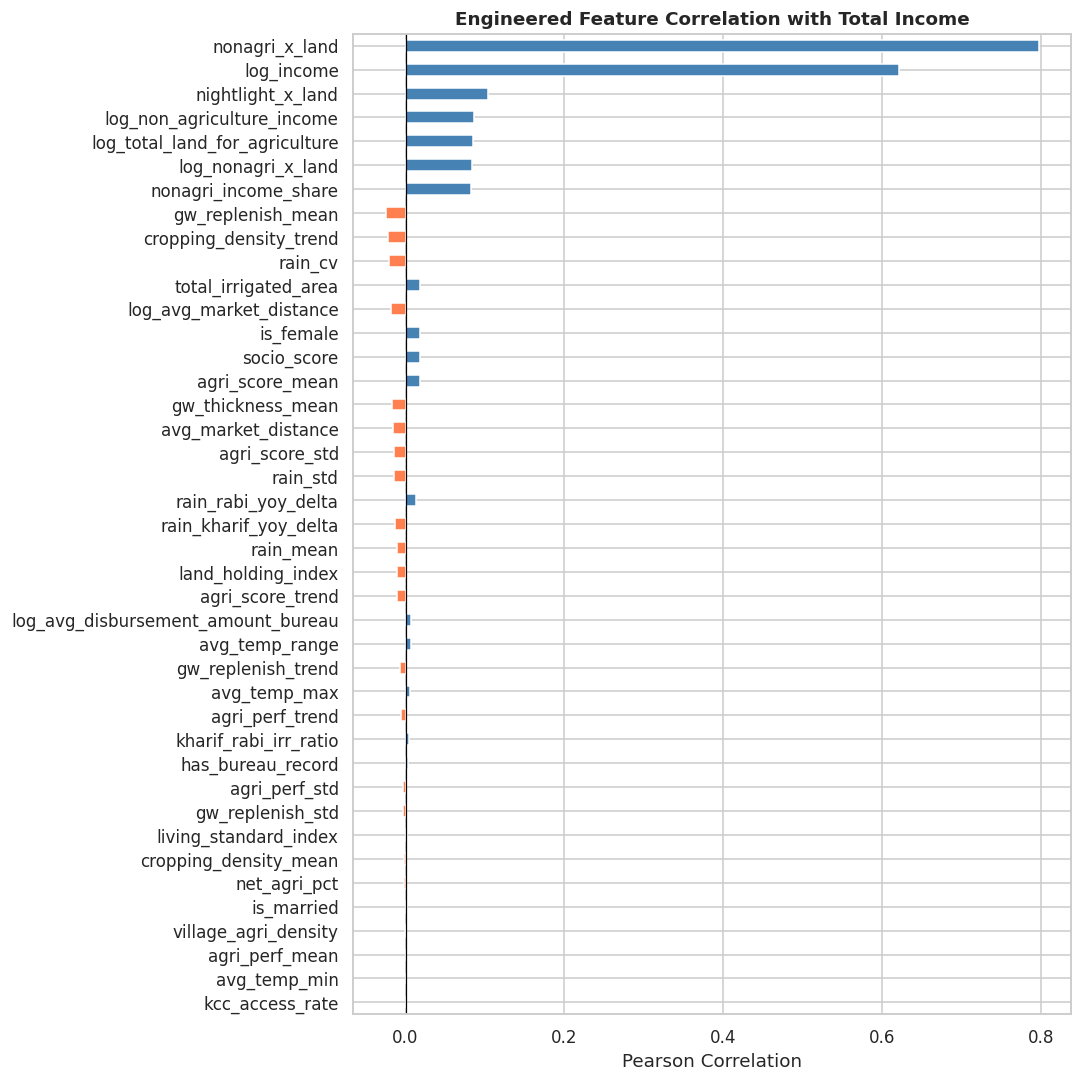

,Target_Variable/Total Income
nonagri_x_land,0.797341
log_income,0.621830
nightlight_x_land,0.104279
log_non_agriculture_income,0.086673
log_total_land_for_agriculture,0.085220
log_nonagri_x_land,0.084291
nonagri_income_share,0.082493
gw_replenish_mean,-0.024743
cropping_density_trend,-0.022237
rain_cv,-0.020545


In [ ]:
new_features = [
    'log_income',
    'log_non_agriculture_income', 'log_total_land_for_agriculture',
    'log_avg_disbursement_amount_bureau', 'has_bureau_record',
    'nonagri_x_land', 'log_nonagri_x_land', 'nightlight_x_land', 'nonagri_income_share',
    'agri_score_mean', 'agri_score_std', 'agri_score_trend',
    'agri_perf_mean', 'agri_perf_std', 'agri_perf_trend',
    'rain_mean', 'rain_std', 'rain_cv', 'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta',
    'gw_replenish_mean', 'gw_replenish_std', 'gw_replenish_trend', 'gw_thickness_mean',
    'kharif_rabi_irr_ratio', 'total_irrigated_area',
    'cropping_density_mean', 'cropping_density_trend',
    'avg_temp_min', 'avg_temp_max', 'avg_temp_range',
    'living_standard_index',
    'socio_score', 'land_holding_index',
    'net_agri_pct', 'village_agri_density', 'avg_market_distance', 'log_avg_market_distance',
    'is_female', 'is_married', 'kcc_access_rate',
]
new_features = [f for f in new_features if f in df.columns]

print(f'Total new features created: {len(new_features)}')
print()

feat_df = df[new_features + [TARGET]].copy()
corr = feat_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if v > 0 else 'coral' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Engineered Feature Correlation with Total Income', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

corr

## 12. Save the Feature-Engineered Dataset

In [ ]:
all_keep = new_features + [
    'FarmerID', 'State', 'REGION', 'DISTRICT', 'VILLAGE',
    'soil type', 'water bodies', 'socio ecological zone',
    TARGET
]
all_keep = [c for c in all_keep if c in df.columns]

df_out = df[all_keep].copy()

In [ ]:
# from google.colab import files

# # Save the DataFrame to the Colab environment's local storage
# df_out.to_csv('your_filename22.csv', index=False)

# # Trigger a download to your local machine
# files.download('your_filename22.csv')

In [ ]:
df_out.reset_index(drop=True, inplace=True)

In [ ]:
df_out

,log_income,log_non_agriculture_income,log_total_land_for_agriculture,log_avg_disbursement_amount_bureau,has_bureau_record,nonagri_x_land,log_nonagri_x_land,nightlight_x_land,nonagri_income_share,agri_score_mean,...,kcc_access_rate,FarmerID,State,REGION,DISTRICT,VILLAGE,soil type,water bodies,socio ecological zone,Target_Variable/Total Income
0,14.272936,13.304687,2.639057,0.000000,0,7800000.0,15.869634,11.18,0.821917,25.235000,...,99.91,1887256993454030,ODISHA,EAST,MALKANGIRI,Malkangiri,Red and lateritic Soils,['water'],EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,1580000
1,13.815512,13.304687,1.791759,0.000000,0,3000000.0,14.914123,3.50,0.923076,12.400000,...,99.72,1106879440316580,TELANGANA,SOUTH,MAHABUBABAD,Mahabubabad,Mixed Red and Black Soils,[None],DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,1000000
2,13.957011,12.676079,2.197225,12.225880,1,2560000.0,14.755518,7.12,0.799998,28.028333,...,99.42,3650476011422490,TELANGANA,SOUTH,SURYAPET,Lingala,Mixed Red and Black Soils,['river'],DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,1152000
3,13.304687,12.677329,1.945910,0.000000,0,1922400.0,14.469085,5.70,0.842269,14.900000,...,96.20,1663099265314970,UTTAR PRADESH,NORTH,MAINPURI,Lalupura,Alluvial-derived Soils (with saline phases),['river'],NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,600000
4,13.785052,0.000000,1.791759,0.000000,0,0.0,0.000000,4.90,0.000000,16.371667,...,88.43,3523662478105830,MADHYA PRADESH,CENTRAL,HOSHANGABAD,Amgaon,Red and lateritic Soils,"['river, water']",EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43154,13.604791,12.100718,2.397895,9.886731,1,1800000.0,14.403298,8.90,0.642855,31.093333,...,89.54,2011619838654310,MADHYA PRADESH,CENTRAL,VIDISHA,Aurangpur,Deep Black soils (with shallow and medium Blac...,[None],CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,810000
43155,13.567050,13.142168,2.197225,0.000000,0,4080000.0,15.221608,7.60,0.864405,31.793333,...,98.29,6069817994550520,ODISHA,EAST,JAJAPUR,Dattapur,Shallow Black Soils (with medium and deep Blac...,[None],DECCAN PLATU HOT SEMI-ARID ECO-REGION,780000
43156,13.458837,0.000000,2.302585,11.555356,1,0.0,0.000000,8.82,0.000000,21.415000,...,99.24,1670777866848000,ANDHRA PRADESH,SOUTH,KRISHNA,Bheemavaram,Mixed Red and Black Soils,[None],DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,700000
43157,13.592368,12.206078,2.397895,0.000000,0,2000000.0,14.508658,9.30,0.666664,27.161667,...,90.21,7825441475417380,MADHYA PRADESH,CENTRAL,GUNA,Ajronda,Deep Black soils (with shallow and medium Blac...,['riverbank'],CENTRAL HIGHLANDS (MALWA AND BUNDELKHAND) HOT...,800000


In [ ]:
df_out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43159 entries, 0 to 43158
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   log_income                          43159 non-null  float64
 1   log_non_agriculture_income          43159 non-null  float64
 2   log_total_land_for_agriculture      43159 non-null  float64
 3   log_avg_disbursement_amount_bureau  43159 non-null  float64
 4   has_bureau_record                   43159 non-null  int64  
 5   nonagri_x_land                      43159 non-null  float64
 6   log_nonagri_x_land                  43159 non-null  float64
 7   nightlight_x_land                   43159 non-null  float64
 8   nonagri_income_share                43159 non-null  float64
 9   agri_score_mean                     43159 non-null  float64
 10  agri_score_std                      43159 non-null  float64
 11  agri_score_trend                    43159

In [ ]:
# from google.colab import files
# df.to_csv('your_filename.csv', index=False)

# files.download('your_filename.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
    print('XGBoost available ✓')
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    XGB_AVAILABLE = False
    print('XGBoost not found — using GradientBoosting. Install: pip install xgboost')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
SEED = 42
TARGET = 'Target_Variable/Total Income'

print('Libraries loaded ✓')

XGBoost available ✓
Libraries loaded ✓


In [ ]:
df_train = df_out.copy()

print(f'Train shape: {df_train.shape}')
print(f'Columns: {df_train.columns.tolist()}')

Train shape: (43159, 50)
Columns: ['log_income', 'log_non_agriculture_income', 'log_total_land_for_agriculture', 'log_avg_disbursement_amount_bureau', 'has_bureau_record', 'nonagri_x_land', 'log_nonagri_x_land', 'nightlight_x_land', 'nonagri_income_share', 'agri_score_mean', 'agri_score_std', 'agri_score_trend', 'agri_perf_mean', 'agri_perf_std', 'agri_perf_trend', 'rain_mean', 'rain_std', 'rain_cv', 'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta', 'gw_replenish_mean', 'gw_replenish_std', 'gw_replenish_trend', 'gw_thickness_mean', 'kharif_rabi_irr_ratio', 'total_irrigated_area', 'cropping_density_mean', 'cropping_density_trend', 'avg_temp_min', 'avg_temp_max', 'avg_temp_range', 'living_standard_index', 'socio_score', 'land_holding_index', 'net_agri_pct', 'village_agri_density', 'avg_market_distance', 'log_avg_market_distance', 'is_female', 'is_married', 'kcc_access_rate', 'FarmerID', 'State', 'REGION', 'DISTRICT', 'VILLAGE', 'soil type', 'water bodies', 'socio ecological zone', 'Target_

In [ ]:
def apply_feature_engineering(df):
    """
    Applies the exact same feature engineering as the EDA notebook.
    Works on both train_data.csv and test_data.csv since they share the same raw columns.

    Steps mirror the notebook in order:
    1. Core log transforms & interactions
    2. Agriculture score features
    3. Agriculture performance features
    4. Rainfall features
    5. Groundwater features
    6. Irrigated area & cropping density
    7. Temperature parsing
    8. Living standard index
    9. Categorical ordinal encoding
    10. Geographic/infrastructure features
    11. Demographic features
    12. Credit access feature
    """
    df = df.copy()

    #1. Core log transforms & interactions
    non_agri = pd.to_numeric(df.get('Non_Agriculture_Income', 0), errors='coerce').fillna(0)
    land     = pd.to_numeric(df.get('Total_Land_For_Agriculture', 0), errors='coerce').fillna(0)
    disb     = pd.to_numeric(df.get('Avg_Disbursement_Amount_Bureau', 0), errors='coerce').fillna(0)
    night    = pd.to_numeric(df.get(' Night light index', 0), errors='coerce').fillna(0)

    df['log_non_agriculture_income']       = np.log1p(non_agri)
    df['log_total_land_for_agriculture']   = np.log1p(land)
    df['log_avg_disbursement_amount_bureau'] = np.log1p(disb)
    df['has_bureau_record']                = (disb > 0).astype(int)

    df['nonagri_x_land']     = non_agri * land
    df['log_nonagri_x_land'] = np.log1p(df['nonagri_x_land'])
    df['nightlight_x_land']  = night * land

    total_raw = pd.to_numeric(df.get(TARGET, np.nan), errors='coerce') if TARGET in df.columns else None
    if total_raw is not None:
        df['nonagri_income_share'] = non_agri / (total_raw + 1)
    else:
        # For test data: use non_agri / (non_agri + land*1000 + 1) as proxy
        df['nonagri_income_share'] = non_agri / (non_agri + land * 1000 + 1)

    #2. Agriculture score features
    agri_score_map = {
        'K022': 'Kharif Seasons  Agricultural Score in 2022',
        'R022': 'Rabi Seasons Agricultural Score in 2022',
        'K021': 'Kharif Seasons Agricultural Score in 2021',
        'R021': 'Rabi Seasons Agricultural Score in 2021',
        'K020': 'Kharif Seasons Agricultural Score in 2020',
        'R020': 'Rabi Seasons Agricultural Score in 2020',
    }
    agri_score_map = {k: v for k, v in agri_score_map.items() if v in df.columns}
    if agri_score_map:
        agri_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                                for k, v in agri_score_map.items()})
        df['agri_score_mean']  = agri_df.mean(axis=1)
        df['agri_score_std']   = agri_df.std(axis=1).fillna(0)
        if 'K022' in agri_df and 'K020' in agri_df:
            df['agri_score_trend'] = agri_df['K022'] - agri_df['K020']
        else:
            df['agri_score_trend'] = 0
    else:
        df['agri_score_mean'] = df['agri_score_std'] = df['agri_score_trend'] = 0

    #3. Agriculture performance features
    agri_perf_map = {
        'K022': 'Kharif Seasons  Agricultural performance in 2022',
        'R022': 'Rabi Seasons Agricultural performance in 2022',
        'K021': 'Kharif Seasons Agricultural performance in 2021',
        'R021': 'Rabi Seasons Agricultural performance in 2021',
        'K020': 'Kharif Seasons Agricultural performance in 2020',
        'R020': 'Rabi Seasons Agricultural performance in 2020',
    }
    agri_perf_map = {k: v for k, v in agri_perf_map.items() if v in df.columns}
    if agri_perf_map:
        perf_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                                for k, v in agri_perf_map.items()})
        df['agri_perf_mean']  = perf_df.mean(axis=1)
        df['agri_perf_std']   = perf_df.std(axis=1).fillna(0)
        if 'K022' in perf_df and 'K020' in perf_df:
            df['agri_perf_trend'] = perf_df['K022'] - perf_df['K020']
        else:
            df['agri_perf_trend'] = 0
    else:
        df['agri_perf_mean'] = df['agri_perf_std'] = df['agri_perf_trend'] = 0

    #4. Rainfall features
    rain_cols = {
        'K022': 'K022-Seasonal Average Rainfall (mm)',
        'R022': 'R022-Seasonal Average Rainfall (mm)',
        'K021': 'K021-Seasonal Average Rainfall (mm)',
        'R021': 'R021-Seasonal Average Rainfall (mm)',
        'R020': 'R020-Seasonal Average Rainfall (mm)',
    }
    rain_cols = {k: v for k, v in rain_cols.items() if v in df.columns}
    if rain_cols:
        rain_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                                for k, v in rain_cols.items()})
        df['rain_mean'] = rain_df.mean(axis=1)
        df['rain_std']  = rain_df.std(axis=1).fillna(0)
        df['rain_cv']   = df['rain_std'] / (df['rain_mean'] + 1)
        df['rain_kharif_yoy_delta'] = rain_df.get('K022', 0) - rain_df.get('K021', 0)
        df['rain_rabi_yoy_delta']   = rain_df.get('R022', 0) - rain_df.get('R021', 0)
    else:
        for f in ['rain_mean','rain_std','rain_cv','rain_kharif_yoy_delta','rain_rabi_yoy_delta']:
            df[f] = 0

    #5. Groundwater features
    gw_rep_map = {
        'k022': 'k022-average groundwater replenishment rate',
        'r022': 'r022-average groundwater replenishment rate',
        'k021': 'k021-average groundwater replenishment rate',
        'r021': 'r021-average groundwater replenishment rate',
        'k020': 'k020-average groundwater replenishment rate',
        'r020': 'r020-average groundwater replenishment rate',
    }
    # Test data has different column names for groundwater — check and map
    gw_rep_map_test = {
        'k022': 'Kharif Seasons  Seasonal average groundwater replenishment rate (cm) in 2022',
        'r022': 'Rabi Seasons  Seasonal average groundwater replenishment rate (cm) in 2022',
        'k021': 'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2021',
        'r021': 'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2021',
        'k020': 'Kharif Seasons Seasonal average groundwater replenishment rate (cm) in 2020',
        'r020': 'Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020',
    }
    # Use whichever set of columns is present
    gw_rep_active = {k: v for k, v in gw_rep_map.items() if v in df.columns}
    if not gw_rep_active:
        gw_rep_active = {k: v for k, v in gw_rep_map_test.items() if v in df.columns}
    if gw_rep_active:
        gw_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                              for k, v in gw_rep_active.items()})
        df['gw_replenish_mean']  = gw_df.mean(axis=1)
        df['gw_replenish_std']   = gw_df.std(axis=1).fillna(0)
        df['gw_replenish_trend'] = gw_df.get('k022', gw_df.iloc[:, 0]) - gw_df.get('k020', gw_df.iloc[:, -1])
    else:
        df['gw_replenish_mean'] = df['gw_replenish_std'] = df['gw_replenish_trend'] = 0

    gw_thick_map = {
        'k022': 'k022-average groundwater thickness',
        'r022': 'r022-avg groundwater thickness',
        'k021': 'k021-average groundwater thickness',
        'r021': 'r021-avg groundwater thickness',
        'k020': 'k020-average groundwater thickness',
        'r020': 'r020-avg groundwater thickness',
    }
    gw_thick_map_test = {
        'k022': 'Kharif Seasons  Seasonal average groundwater thickness (cm) in 2022',
        'r022': 'Rabi Seasons  Seasonal average groundwater thickness (cm) in 2022',
        'k021': 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2021',
        'r021': 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2021',
        'k020': 'Kharif Seasons Seasonal average groundwater thickness (cm) in 2020',
        'r020': 'Rabi Seasons Seasonal average groundwater thickness (cm) in 2020',
    }
    gw_thick_active = {k: v for k, v in gw_thick_map.items() if v in df.columns}
    if not gw_thick_active:
        gw_thick_active = {k: v for k, v in gw_thick_map_test.items() if v in df.columns}
    if gw_thick_active:
        thick_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                                 for k, v in gw_thick_active.items()})
        df['gw_thickness_mean'] = thick_df.mean(axis=1)
    else:
        df['gw_thickness_mean'] = 0

    #6. Irrigated area & cropping density
    # Train col names
    k_irr_col = 'k022-irrigated area'
    r_irr_col = 'r022-irrigated area'
    # Test col names
    if k_irr_col not in df.columns:
        k_irr_col = 'Kharif Seasons  Irrigated area in 2022'
    if r_irr_col not in df.columns:
        r_irr_col = 'Rabi Seasons  Season Irrigated area in 2022'

    k_irr = pd.to_numeric(df.get(k_irr_col, 0), errors='coerce').fillna(0)
    r_irr = pd.to_numeric(df.get(r_irr_col, 0), errors='coerce').fillna(0)
    df['kharif_rabi_irr_ratio'] = k_irr / (r_irr + 1)
    df['total_irrigated_area']  = k_irr + r_irr

    crop_map = {
        'k022': 'k022-cropping density',
        'r022': 'r022-cropping density',
        'k021': 'k021-cropping density',
        'r021': 'r021-cropping density',
        'k020': 'k020-cropping density',
        'r020': 'r020-cropping density',
    }
    crop_map_test = {
        'k022': 'Kharif Seasons  Cropping density in 2022',
        'r022': 'Rabi Seasons Cropping density in 2022',
        'k021': 'Kharif Seasons Cropping density in 2021',
        'r021': 'Rabi Seasons Cropping density in 2021',
        'k020': 'Kharif Seasons Kharif Season Irrigated area in 2020',
        'r020': 'Rabi Seasons Cropping density in 2020',
    }
    crop_active = {k: v for k, v in crop_map.items() if v in df.columns}
    if not crop_active:
        crop_active = {k: v for k, v in crop_map_test.items() if v in df.columns}
    if crop_active:
        crop_df = pd.DataFrame({k: pd.to_numeric(df[v], errors='coerce')
                                for k, v in crop_active.items()})
        df['cropping_density_mean'] = crop_df.mean(axis=1)
        df['cropping_density_trend'] = (
            crop_df.get('k022', crop_df.iloc[:, 0]) - crop_df.get('k020', crop_df.iloc[:, -1])
        )
    else:
        df['cropping_density_mean'] = df['cropping_density_trend'] = 0

    #7. Temperature parsing
    temp_col_map = {
        'K022-Ambient temperature (min & max)': ('k022_temp_min', 'k022_temp_max'),
        'R022-Ambient temperature (min & max)': ('r022_temp_min', 'r022_temp_max'),
        'K021-Ambient temperature (min & max)': ('k021_temp_min', 'k021_temp_max'),
        'R021-Ambient temperature (min & max)': ('r021_temp_min', 'r021_temp_max'),
        'R020-Ambient temperature (min & max)': ('r020_temp_min', 'r020_temp_max'),
    }
    temp_min_cols, temp_max_cols = [], []
    for col, (min_name, max_name) in temp_col_map.items():
        if col not in df.columns:
            continue
        split = df[col].astype(str).str.split('/', expand=True)
        df[min_name] = pd.to_numeric(split[0].str.strip(), errors='coerce')
        df[max_name] = pd.to_numeric(split[1].str.strip(), errors='coerce') if split.shape[1] > 1 else np.nan
        temp_min_cols.append(min_name)
        temp_max_cols.append(max_name)

    df['avg_temp_min']   = df[temp_min_cols].mean(axis=1) if temp_min_cols else 0
    df['avg_temp_max']   = df[temp_max_cols].mean(axis=1) if temp_max_cols else 0
    df['avg_temp_range'] = df['avg_temp_max'] - df['avg_temp_min']

    #8. Living standard index
    living_cols = [
        'Perc_of_house_with_6plus_room',
        'perc_of_pop_living_in_hh_electricity',
        'perc_Households_with_Pucca_House_That_Has_More_Than_3_Rooms',
        'Households_with_improved_Sanitation_Facility',
        'mat_roof_Metal_GI_Asbestos_sheets',
        'perc_of_Wall_material_with_Burnt_brick',
    ]
    living_cols = [c for c in living_cols if c in df.columns]
    if living_cols:
        living_df_num = df[living_cols].apply(pd.to_numeric, errors='coerce')
        # MinMax scale using column-wise min/max (per-column normalise)
        living_scaled = living_df_num.apply(
            lambda col: (col - col.min()) / (col.max() - col.min() + 1e-8)
        )
        df['living_standard_index'] = living_scaled.fillna(0.5).mean(axis=1)
    else:
        df['living_standard_index'] = 0.5

    #9. Ordinal encoding of agri/socio categories
    ordinal_map = {'Good': 2, 'Average': 1, 'Poor': 0}
    agri_cat_cols = [c for c in df.columns if 'Village category based on Agri' in c]
    for col in agri_cat_cols:
        new_col = 'agri_cat_' + col[:4].lower().strip()
        df[new_col] = df[col].map(ordinal_map).fillna(1)

    socio_cat_cols = [c for c in df.columns if 'socio-economic parameters (Good' in c]
    if socio_cat_cols:
        df['socio_cat_encoded'] = df[socio_cat_cols[0]].map(ordinal_map).fillna(1)

    vscore_col = ' Village score based on socio-economic parameters (0 to 100)'
    # Test data has slightly different column name
    vscore_alt = 'KO22-Village score based on socio-economic parameters (0 to 100)'
    if vscore_col in df.columns:
        df['socio_score'] = pd.to_numeric(df[vscore_col], errors='coerce').fillna(50)
    elif vscore_alt in df.columns:
        df['socio_score'] = pd.to_numeric(df[vscore_alt], errors='coerce').fillna(50)
    else:
        df['socio_score'] = 50

    lhi_col = ' Land Holding Index source (Total Agri Area/ no of people)'
    df['land_holding_index'] = pd.to_numeric(df.get(lhi_col, 0), errors='coerce').fillna(0)

    #10. Geographic & infrastructure features
    # Net agri pct — train uses one name, test may use another
    net_agri_pct_col = 'Net Agri area (% of total geog area)'
    net_agri_pct_alt = 'K022-Net Agri area (% of total geog area)-'
    if net_agri_pct_col in df.columns:
        df['net_agri_pct'] = pd.to_numeric(df[net_agri_pct_col], errors='coerce').fillna(0)
    elif net_agri_pct_alt in df.columns:
        df['net_agri_pct'] = pd.to_numeric(df[net_agri_pct_alt], errors='coerce').fillna(0)
    else:
        df['net_agri_pct'] = 0

    net_ha_col = 'Net Agri area (in Ha)'
    net_ha_alt = 'K022-Net Agri area (in Ha)-'
    geo_ha_col = 'Total Geographical Area (in Hectares)'
    geo_ha_alt = 'K022-Total Geographical Area (in Hectares)-'
    net_ha  = pd.to_numeric(df.get(net_ha_col, df.get(net_ha_alt, 0)), errors='coerce').fillna(0)
    geo_ha  = pd.to_numeric(df.get(geo_ha_col, df.get(geo_ha_alt, 1)), errors='coerce').fillna(1)
    df['village_agri_density'] = net_ha / (geo_ha + 1)

    # Mandi & railway distance — train vs test have different column names
    mandi_col   = 'mandi distance' if 'mandi distance' in df.columns else 'K022-Proximity to nearest mandi (Km)'
    railway_col = 'nearest railway distance' if 'nearest railway distance' in df.columns else 'K022-Proximity to nearest railway (Km)'
    mandi_dist   = pd.to_numeric(df.get(mandi_col, 0), errors='coerce').fillna(0)
    railway_dist = pd.to_numeric(df.get(railway_col, 0), errors='coerce').fillna(0)
    df['avg_market_distance']     = (mandi_dist + railway_dist) / 2
    df['log_avg_market_distance'] = np.log1p(df['avg_market_distance'])

    #11. Demographic features
    if 'SEX' in df.columns:
        df['is_female']  = (df['SEX'] == 'F').astype(int)
        df['is_married'] = (df['MARITAL_STATUS'] == 'M').astype(int) if 'MARITAL_STATUS' in df.columns else 0
    else:
        df['is_female'] = df['is_married'] = 0

    #12. Credit access feature
    kcc_col = 'perc_Households_do_not_have_KCC_With_The_Credit_Limit_Of_50k'
    if kcc_col in df.columns:
        df['kcc_access_rate'] = 100 - pd.to_numeric(df[kcc_col], errors='coerce').fillna(50)
    else:
        df['kcc_access_rate'] = 50

    return df


#Load and process raw test data
df_test_raw = pd.read_csv('/content/drive/MyDrive/test_data.csv')
df_test_fe  = apply_feature_engineering(df_test_raw)

print(f'Test raw shape : {df_test_raw.shape}')
print(f'Test after FE  : {df_test_fe.shape}')
print('Feature engineering applied to test data ✓')

Test raw shape : (4797, 104)
Test after FE  : (4797, 157)
Feature engineering applied to test data ✓


In [ ]:
df_test_fe.columns

Index(['FarmerID', 'State', 'REGION', 'SEX', 'CITY', 'Zipcode', 'DISTRICT',
       'VILLAGE', 'MARITAL_STATUS', 'Location',
       ...
       'socio_cat_encoded', 'socio_score', 'land_holding_index',
       'net_agri_pct', 'village_agri_density', 'avg_market_distance',
       'log_avg_market_distance', 'is_female', 'is_married',
       'kcc_access_rate'],
      dtype='object', length=157)

In [ ]:
GLOBAL_MEAN = df_train[TARGET].mean()
SMOOTH = 50  # smoothing strength — higher = shrinks more toward global mean

# Stores the encoding maps learned from train — applied to test
TARGET_ENCODERS = {}

def fit_target_encode(train_series, target_series, smooth=SMOOTH):
    """Learns smoothed target encoding from train. Returns a mapping dict."""
    stats = target_series.groupby(train_series).agg(['mean', 'count'])
    stats['encoded'] = (
        stats['count'] * stats['mean'] + smooth * GLOBAL_MEAN
    ) / (stats['count'] + smooth)
    return stats['encoded'].to_dict()

# Learn encodings from train, apply to both train and test
for col in ['State', 'REGION', 'DISTRICT']:
    if col in df_train.columns:
        enc_map = fit_target_encode(df_train[col], df_train[TARGET])
        TARGET_ENCODERS[col] = enc_map
        df_train[f'{col}_te'] = df_train[col].map(enc_map).fillna(GLOBAL_MEAN)
        # Apply to test_fe (which was built from test_raw, still has State/REGION/DISTRICT)
        if col in df_test_fe.columns:
            df_test_fe[f'{col}_te'] = df_test_fe[col].map(enc_map).fillna(GLOBAL_MEAN)
        print(f'{col} target encoded ✓  ({len(enc_map)} unique values)')

# Soil type — label encode (not target encode, it's a static geographic property)
SOIL_COL_TRAIN = 'soil type'
SOIL_COL_TEST  = 'Kharif Seasons  Type of soil in 2022'  # canonical from test

le_soil = LabelEncoder()
if SOIL_COL_TRAIN in df_train.columns:
    combined_soil = pd.concat([
        df_train[SOIL_COL_TRAIN],
        df_test_fe[SOIL_COL_TEST] if SOIL_COL_TEST in df_test_fe.columns else pd.Series(dtype=str)
    ], ignore_index=True).fillna('Unknown')
    le_soil.fit(combined_soil)
    df_train['soil_type_enc'] = le_soil.transform(df_train[SOIL_COL_TRAIN].fillna('Unknown'))
    if SOIL_COL_TEST in df_test_fe.columns:
        df_test_fe['soil_type_enc'] = le_soil.transform(df_test_fe[SOIL_COL_TEST].fillna('Unknown'))
    else:
        df_test_fe['soil_type_enc'] = 0
    print('soil_type label encoded ✓')

State target encoded ✓  (17 unique values)
REGION target encoded ✓  (5 unique values)
DISTRICT target encoded ✓  (405 unique values)
soil_type label encoded ✓


In [ ]:
# All features — ordered by expected importance
# Tier 1: High signal (r > 0.08)
# Tier 2: Moderate signal via non-linear interactions (tree model)
# Tier 3: Context/control features

FEATURE_COLS = [
    # Tier 1 — strong signal
    'nonagri_x_land',
    'log_nonagri_x_land',
    'log_non_agriculture_income',
    'log_total_land_for_agriculture',
    'nightlight_x_land',
    'nonagri_income_share',

    # Tier 2 — geographic target encoded
    'State_te', 'REGION_te', 'DISTRICT_te',

    # Tier 2 — credit & bureau
    'log_avg_disbursement_amount_bureau',
    'has_bureau_record',

    # Tier 2 — village & infrastructure
    'socio_score',
    'land_holding_index',
    'log_avg_market_distance',
    'avg_market_distance',
    'soil_type_enc',
    'net_agri_pct',
    'village_agri_density',

    # Tier 2 — agri performance
    'agri_score_mean', 'agri_score_std', 'agri_score_trend',
    'agri_perf_mean', 'agri_perf_std', 'agri_perf_trend',

    # Tier 3 — seasonal volatility
    'rain_mean', 'rain_std', 'rain_cv',
    'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta',
    'gw_replenish_mean', 'gw_replenish_std', 'gw_replenish_trend',
    'gw_thickness_mean',

    # Tier 3 — irrigated area & cropping
    'kharif_rabi_irr_ratio', 'total_irrigated_area',
    'cropping_density_mean', 'cropping_density_trend',

    # Tier 3 — temperature
    'avg_temp_min', 'avg_temp_max', 'avg_temp_range',

    # Tier 3 — living standards & demographics
    'living_standard_index',
    'kcc_access_rate',
    'is_female', 'is_married',
]

# Keep only columns present in both train and test
FEATURE_COLS = [
    c for c in FEATURE_COLS
    if c in df_train.columns and c in df_test_fe.columns
]

print(f'Features used: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

X = df_train[FEATURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)
y = df_train[TARGET]
y_log = np.log1p(y)  # train on log-transformed target

X_test = df_test_fe[FEATURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'\nX train: {X.shape}  |  X test: {X_test.shape}')

Features used: 44
['nonagri_x_land', 'log_nonagri_x_land', 'log_non_agriculture_income', 'log_total_land_for_agriculture', 'nightlight_x_land', 'nonagri_income_share', 'State_te', 'REGION_te', 'DISTRICT_te', 'log_avg_disbursement_amount_bureau', 'has_bureau_record', 'socio_score', 'land_holding_index', 'log_avg_market_distance', 'avg_market_distance', 'soil_type_enc', 'net_agri_pct', 'village_agri_density', 'agri_score_mean', 'agri_score_std', 'agri_score_trend', 'agri_perf_mean', 'agri_perf_std', 'agri_perf_trend', 'rain_mean', 'rain_std', 'rain_cv', 'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta', 'gw_replenish_mean', 'gw_replenish_std', 'gw_replenish_trend', 'gw_thickness_mean', 'kharif_rabi_irr_ratio', 'total_irrigated_area', 'cropping_density_mean', 'cropping_density_trend', 'avg_temp_min', 'avg_temp_max', 'avg_temp_range', 'living_standard_index', 'kcc_access_rate', 'is_female', 'is_married']

X train: (43159, 44)  |  X test: (4797, 44)


In [ ]:
X

,nonagri_x_land,log_nonagri_x_land,log_non_agriculture_income,log_total_land_for_agriculture,nightlight_x_land,nonagri_income_share,State_te,REGION_te,DISTRICT_te,log_avg_disbursement_amount_bureau,...,total_irrigated_area,cropping_density_mean,cropping_density_trend,avg_temp_min,avg_temp_max,avg_temp_range,living_standard_index,kcc_access_rate,is_female,is_married
0,7800000.0,15.869634,13.304687,2.639057,11.18,0.821917,1.109849e+06,9.413000e+05,1.510859e+06,0.000000,...,115.22,57.011667,21.11,21.772,30.620,8.848,0.274161,99.91,0,1
1,3000000.0,14.914123,13.304687,1.791759,3.50,0.923076,1.158228e+06,1.301143e+06,9.304051e+05,0.000000,...,53.83,55.021667,5.70,22.428,31.240,8.812,0.444740,99.72,0,1
2,2560000.0,14.755518,12.676079,2.197225,7.12,0.799998,1.158228e+06,1.301143e+06,1.289410e+06,12.225880,...,129.12,37.000000,21.03,23.244,32.044,8.800,0.450221,99.42,0,1
3,1922400.0,14.469085,12.677329,1.945910,5.70,0.842269,8.423227e+05,1.129653e+06,1.003244e+06,0.000000,...,91.56,56.228333,-31.30,17.350,27.884,10.534,0.441068,96.20,0,1
4,0.0,0.000000,0.000000,1.791759,4.90,0.000000,1.240862e+06,1.225883e+06,1.060169e+06,0.000000,...,50.22,28.801667,18.40,21.360,30.864,9.504,0.339391,88.43,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43154,1800000.0,14.403298,12.100718,2.397895,8.90,0.642855,1.240862e+06,1.225883e+06,1.905684e+06,9.886731,...,168.00,52.331667,32.45,18.414,29.252,10.838,0.318697,89.54,0,1
43155,4080000.0,15.221608,13.142168,2.197225,7.60,0.864405,1.109849e+06,9.413000e+05,1.005861e+06,0.000000,...,121.76,58.296667,-16.47,20.514,30.010,9.496,0.305733,98.29,0,1
43156,0.0,0.000000,0.000000,2.302585,8.82,0.000000,1.322658e+06,1.301143e+06,1.524156e+06,11.555356,...,49.42,32.921667,15.35,23.370,32.032,8.662,0.430409,99.24,0,1
43157,2000000.0,14.508658,12.206078,2.397895,9.30,0.666664,1.240862e+06,1.225883e+06,2.509832e+06,0.000000,...,133.98,58.856667,12.02,18.600,29.112,10.512,0.254559,90.21,0,1


In [ ]:
X_test

,nonagri_x_land,log_nonagri_x_land,log_non_agriculture_income,log_total_land_for_agriculture,nightlight_x_land,nonagri_income_share,State_te,REGION_te,DISTRICT_te,log_avg_disbursement_amount_bureau,...,total_irrigated_area,cropping_density_mean,cropping_density_trend,avg_temp_min,avg_temp_max,avg_temp_range,living_standard_index,kcc_access_rate,is_female,is_married
0,2000000.0,14.508658,12.206078,2.397895,9.30,0.952376,1.240862e+06,1.225883e+06,1.905684e+06,11.141259,...,169.80,85.400000,-50.48,18.414,29.252,10.838,0.324654,89.38,0,1
1,0.0,0.000000,0.000000,2.833213,15.04,0.000000,1.623052e+06,1.129653e+06,1.784352e+06,12.304841,...,144.48,62.118333,-17.56,17.306,27.770,10.464,0.519576,95.46,0,1
2,0.0,0.000000,0.000000,2.397895,9.50,0.000000,1.240862e+06,1.225883e+06,9.068597e+05,0.000000,...,120.37,47.358333,16.15,18.676,28.926,10.250,0.293321,97.08,0,0
3,1400000.0,14.151984,13.458837,1.098612,1.86,0.997150,1.782343e+06,1.129653e+06,1.713368e+06,0.000000,...,92.56,60.933333,-7.78,16.764,27.254,10.490,0.566794,92.43,0,0
4,1200000.0,13.997833,11.512935,2.564949,11.52,0.892849,1.240862e+06,1.225883e+06,1.273154e+06,0.000000,...,150.06,63.418333,30.29,18.604,28.966,10.362,0.257771,95.62,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4792,2000000.0,14.508658,12.206078,2.397895,9.60,0.952376,1.322658e+06,1.301143e+06,1.203021e+06,0.000000,...,113.91,64.451667,-18.89,23.324,31.684,8.360,0.401905,99.99,0,1
4793,0.0,0.000000,0.000000,2.397895,9.60,0.000000,1.240862e+06,1.225883e+06,1.312869e+06,13.607257,...,154.58,75.570000,-10.65,19.878,29.864,9.986,0.417966,91.94,0,1
4794,7168050.0,15.785144,14.281067,1.704748,3.87,0.997182,1.240862e+06,1.225883e+06,2.950836e+06,0.000000,...,122.97,60.488333,-7.06,18.738,29.500,10.762,0.474320,97.56,0,1
4795,680000.0,13.429850,12.736704,1.098612,1.94,0.994149,1.216678e+06,1.189534e+06,1.311561e+06,0.000000,...,86.92,61.391667,-42.32,20.596,29.718,9.122,0.500000,50.00,0,1


In [ ]:
df_train.columns

Index(['log_income', 'log_non_agriculture_income',
       'log_total_land_for_agriculture', 'log_avg_disbursement_amount_bureau',
       'has_bureau_record', 'nonagri_x_land', 'log_nonagri_x_land',
       'nightlight_x_land', 'nonagri_income_share', 'agri_score_mean',
       'agri_score_std', 'agri_score_trend', 'agri_perf_mean', 'agri_perf_std',
       'agri_perf_trend', 'rain_mean', 'rain_std', 'rain_cv',
       'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta', 'gw_replenish_mean',
       'gw_replenish_std', 'gw_replenish_trend', 'gw_thickness_mean',
       'kharif_rabi_irr_ratio', 'total_irrigated_area',
       'cropping_density_mean', 'cropping_density_trend', 'avg_temp_min',
       'avg_temp_max', 'avg_temp_range', 'living_standard_index',
       'socio_score', 'land_holding_index', 'net_agri_pct',
       'village_agri_density', 'avg_market_distance',
       'log_avg_market_distance', 'is_female', 'is_married', 'kcc_access_rate',
       'FarmerID', 'State', 'REGION', 'DISTRICT', 'VI

In [ ]:
X.columns

Index(['nonagri_x_land', 'log_nonagri_x_land', 'log_non_agriculture_income',
       'log_total_land_for_agriculture', 'nightlight_x_land',
       'nonagri_income_share', 'State_te', 'REGION_te', 'DISTRICT_te',
       'log_avg_disbursement_amount_bureau', 'has_bureau_record',
       'socio_score', 'land_holding_index', 'log_avg_market_distance',
       'avg_market_distance', 'soil_type_enc', 'net_agri_pct',
       'village_agri_density', 'agri_score_mean', 'agri_score_std',
       'agri_score_trend', 'agri_perf_mean', 'agri_perf_std',
       'agri_perf_trend', 'rain_mean', 'rain_std', 'rain_cv',
       'rain_kharif_yoy_delta', 'rain_rabi_yoy_delta', 'gw_replenish_mean',
       'gw_replenish_std', 'gw_replenish_trend', 'gw_thickness_mean',
       'kharif_rabi_irr_ratio', 'total_irrigated_area',
       'cropping_density_mean', 'cropping_density_trend', 'avg_temp_min',
       'avg_temp_max', 'avg_temp_range', 'living_standard_index',
       'kcc_access_rate', 'is_female', 'is_married'],
  

In [ ]:
# from google.colab import files

# # Save the DataFrame to the Colab environment's local storage
# df_train.to_csv('fe_train.csv', index=False)

# # Trigger a download to your local machine
# files.download('fe_train.csv')

In [ ]:
# lr_model = LinearRegression()
# lr_model.fit(X, y_log)

# lr_val_preds = lr_model.predict(X_test)

# # predictions are in log space, convert back to rupees before measuring MAPE
# # MAPE on log scale would be meaningless, we need actual income
# lr_val_preds_actual = np.expm1(lr_val_preds)
# y_val_actual        = np.expm1(y_val)

# lr_mape = mean_absolute_percentage_error(y_val_actual, lr_val_preds_actual)
# print(f'Linear Regression MAPE: {lr_mape:.4f}  ({lr_mape*100:.2f}%)')

In [ ]:
# ── Confirm variables from EDA notebook are present ──────────────────────────
required = ['X', 'y_log', 'X_test', 'df_test_fe', 'FEATURE_COLS', 'TARGET']
missing  = [v for v in required if v not in dir()]
if missing:
    print(f'⚠️  Missing from EDA notebook: {missing}')
    print('   Run the EDA/FE notebook first, then continue here.')
else:
    print(f'All EDA variables present ✓')
    print(f'X shape      : {X.shape}')
    print(f'X_test shape : {X_test.shape}')
    print(f'Features     : {len(FEATURE_COLS)}')

All EDA variables present ✓
X shape      : (43159, 44)
X_test shape : (4797, 44)
Features     : 44


In [ ]:
# y_log = np.log1p(Target_Variable/Total Income)  — already computed in EDA notebook
# We also keep y_log as 'target' variable name to match modelling notebook convention

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f'Training samples  : {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')

# Helper — MAPE in original rupee scale (not log scale)
def mape_rupees(y_true_log, y_pred_log):
    """Converts both from log space to ₹ before computing MAPE."""
    return mean_absolute_percentage_error(
        np.expm1(y_true_log),
        np.expm1(y_pred_log)
    ) * 100  # return as percentage

Training samples  : 34,527
Validation samples: 8,632


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

print('Imports ready ✓')

# ── Confirm variables from EDA notebook are present ──────────────────────────
required = ['X', 'y_log', 'X_test', 'df_test_fe', 'FEATURE_COLS', 'TARGET']
missing  = [v for v in required if v not in dir()]
if missing:
    print(f'⚠️  Missing from EDA notebook: {missing}')
    print('   Run the EDA/FE notebook first, then continue here.')
else:
    print(f'All EDA variables present ✓')
    print(f'X shape      : {X.shape}')
    print(f'X_test shape : {X_test.shape}')
    print(f'Features     : {len(FEATURE_COLS)}')

Imports ready ✓
All EDA variables present ✓
X shape      : (43159, 44)
X_test shape : (4797, 44)
Features     : 44


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_val_preds = lr_model.predict(X_val)
lr_mape      = mape_rupees(y_val, lr_val_preds)

print(f'Linear Regression — Validation MAPE: {lr_mape:.2f}%')
print('(Baseline to beat)')

Linear Regression — Validation MAPE: 132.62%
(Baseline to beat)


In [ ]:
rf_model_1 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_1.fit(X_train, y_train)

rf1_val_preds = rf_model_1.predict(X_val)
rf1_mape      = mape_rupees(y_val, rf1_val_preds)

print(f'Random Forest (100 trees, default depth) — Validation MAPE: {rf1_mape:.2f}%')

# Quick overfitting check
rf1_train_mape = mape_rupees(y_train, rf_model_1.predict(X_train))
print(f'Random Forest (100 trees) — Train MAPE     : {rf1_train_mape:.2f}%')
print(f'Gap (overfit indicator)   : {rf1_mape - rf1_train_mape:.2f}pp')

Random Forest (100 trees, default depth) — Validation MAPE: 21.08%
Random Forest (100 trees) — Train MAPE     : 7.63%
Gap (overfit indicator)   : 13.45pp


In [ ]:
# More trees + depth cap + min_samples_leaf to reduce overfitting
rf_model_2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_model_2.fit(X_train, y_train)

rf2_val_preds = rf_model_2.predict(X_val)
rf2_mape      = mape_rupees(y_val, rf2_val_preds)

rf2_train_mape = mape_rupees(y_train, rf_model_2.predict(X_train))

print(f'Random Forest (200 trees, depth=15) — Validation MAPE : {rf2_mape:.2f}%')
print(f'Random Forest (200 trees, depth=15) — Train MAPE      : {rf2_train_mape:.2f}%')
print(f'Gap (overfit indicator) : {rf2_mape - rf2_train_mape:.2f}pp')

In [ ]:
results = {
    'Linear Regression'              : lr_mape,
    'Random Forest (100 trees)'      : rf1_mape,
    'Random Forest (200 trees, d=15)': rf2_mape,
}

train_mapes = {
    'Linear Regression'              : mape_rupees(y_train, lr_model.predict(X_train)),
    'Random Forest (100 trees)'      : rf1_train_mape,
    'Random Forest (200 trees, d=15)': rf2_train_mape,
}

print(f'{'Model':<35} {'Train MAPE':>12} {'Val MAPE':>10} {'Gap':>8}')
print('-' * 70)
for name in results:
    tr = train_mapes[name]
    vl = results[name]
    print(f'{name:<35} {tr:>11.2f}% {vl:>9.2f}% {vl-tr:>7.2f}pp')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(results.keys())
val_v  = list(results.values())
tr_v   = [train_mapes[n] for n in names]
x      = range(len(names))
width  = 0.35

bars_tr  = ax.bar([i - width/2 for i in x], tr_v,  width, label='Train MAPE',      color='steelblue', alpha=0.8)
bars_val = ax.bar([i + width/2 for i in x], val_v, width, label='Validation MAPE', color='coral',     alpha=0.8)

ax.bar_label(bars_tr,  fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(bars_val, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('Model Comparison — Train vs Validation MAPE (lower = better)', fontsize=11, fontweight='bold')
ax.legend()
ax.set_ylim(0, max(val_v) * 1.3)
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = min(results, key=results.get)
best_val_mape   = results[best_model_name]

model_map = {
    'Linear Regression'              : lr_model,
    'Random Forest (100 trees)'      : rf_model_1,
    'Random Forest (200 trees, d=15)': rf_model_2,
}
best_model = model_map[best_model_name]

print(f'Best model       : {best_model_name}')
print(f'Validation MAPE  : {best_val_mape:.2f}%')
print()
print('Selection rationale:')
print('  - Lowest validation MAPE = best generalisation on unseen data')
print('  - Checked train/val gap to avoid selecting an overfit model')
print('  - Random Forest handles non-linear feature interactions better than Linear Regression')

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('Top 10 features:')
    print(importances.head(10).to_string())
    print()
    print('Bottom 5 (lowest contribution — candidates for removal):')
    print(importances.tail(5).to_string())

else:
    # Linear Regression — show coefficients instead
    coefs = pd.Series(
        best_model.coef_, index=FEATURE_COLS
    ).sort_values(key=abs, ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['steelblue' if v > 0 else 'coral' for v in coefs.values]
    coefs.plot(kind='barh', ax=ax, color=colors)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 20 Coefficients — Linear Regression', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient value (positive = raises income, negative = lowers)')
    plt.tight_layout()
    plt.show()

In [ ]:
# Convert everything back to ₹ for interpretable plots
y_val_rupees  = np.expm1(y_val)
y_pred_rupees = np.expm1(best_model.predict(X_val))
pct_error     = (y_pred_rupees - y_val_rupees) / y_val_rupees * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted scatter
axes[0].scatter(y_val_rupees, y_pred_rupees, alpha=0.12, s=6, color='steelblue')
lim = max(y_val_rupees.max(), y_pred_rupees.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Income (₹)')
axes[0].set_ylabel('Predicted Income (₹)')
axes[0].set_title('Actual vs Predicted', fontsize=11, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[0].legend(fontsize=8)

# 2. % Error distribution
axes[1].hist(pct_error.clip(-100, 150), bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].axvline(pct_error.median(), color='blue', linestyle='--', linewidth=1,
                label=f'Median error: {pct_error.median():.1f}%')
axes[1].set_title('% Prediction Error Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('% Error (clipped at -100 to +150)')
axes[1].legend(fontsize=8)

# 3. Error by income quartile — where does the model struggle?
val_df = pd.DataFrame({
    'actual': y_val_rupees,
    'abs_pct_err': pct_error.abs()
})
val_df['income_quartile'] = pd.qcut(
    val_df['actual'], 4,
    labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)']
)
quartile_mape = val_df.groupby('income_quartile', observed=True)['abs_pct_err'].mean()
quartile_mape.plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Mean % Error by Income Quartile', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Mean Absolute % Error')
axes[2].set_xlabel('Income Quartile')
axes[2].tick_params(axis='x', rotation=0)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontsize=9)

plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Overall Validation MAPE  : {best_val_mape:.2f}%')
print(f'Median % error           : {pct_error.median():.2f}%  (close to 0 = unbiased)')
print(f'% of predictions within 10% error: {(pct_error.abs() <= 10).mean()*100:.1f}%')
print(f'% of predictions within 20% error: {(pct_error.abs() <= 20).mean()*100:.1f}%')
print(f'% of predictions within 50% error: {(pct_error.abs() <= 50).mean()*100:.1f}%')
print()
print('MAPE by income quartile (above plot):')
print(quartile_mape.to_string())

In [ ]:
# Always retrain on ALL training data (train + val) before predicting on test
# This gives the model maximum data to learn from

if best_model_name == 'Linear Regression':
    final_model = LinearRegression()

elif best_model_name == 'Random Forest (100 trees)':
    final_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

# X and y_log are the full training set from the EDA notebook
final_model.fit(X, y_log)

print(f'Final model  : {best_model_name}')
print(f'Training rows: {len(X):,}  (full training set — no validation holdout)')
print('Retrained on full data ✓')

In [ ]:
# X_test was built in the EDA notebook from test_data.csv
# It already has the same FEATURE_COLS as X, with target encoding applied

log_preds    = final_model.predict(X_test)
income_preds = np.expm1(log_preds)              # inverse of log1p
income_preds = np.clip(income_preds, 0, None)   # no negative incomes

print(f'Predictions generated : {len(income_preds):,}')
print(f'Min predicted income  : ₹{income_preds.min():>15,.0f}')
print(f'Max predicted income  : ₹{income_preds.max():>15,.0f}')
print(f'Mean predicted income : ₹{income_preds.mean():>15,.0f}')
print(f'Median predicted      : ₹{np.median(income_preds):>15,.0f}')

# Sanity check — predicted distribution should look similar to train
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Log scale comparison
axes[0].hist(y_log, bins=50, color='steelblue', alpha=0.65, label='Train (actual)', density=True)
axes[0].hist(log_preds, bins=50, color='coral', alpha=0.65, label='Test (predicted)', density=True)
axes[0].set_title('log(Income) Distribution: Train vs Test Predictions', fontsize=10, fontweight='bold')
axes[0].set_xlabel('log(1 + Income)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Raw scale comparison
train_income = np.expm1(y_log)
axes[1].hist(train_income / 1e5, bins=60, color='steelblue', alpha=0.65,
             label='Train (actual)', density=True)
axes[1].hist(income_preds / 1e5, bins=60, color='coral', alpha=0.65,
             label='Test (predicted)', density=True)
axes[1].set_title('Income Distribution (₹ Lakhs): Train vs Test Predictions', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Income (₹ Lakhs)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print('Sanity check: Train vs Test predicted income statistics')
print(f'  Train median : ₹{np.median(train_income):,.0f}')
print(f'  Test  median : ₹{np.median(income_preds):,.0f}')
diff_pct = abs(np.median(income_preds) - np.median(train_income)) / np.median(train_income) * 100
print(f'  Median diff  : {diff_pct:.1f}%  ', end='')
if diff_pct < 15:
    print('← distributions look consistent ✓')
else:
    print('← large shift, check for data leakage or distribution mismatch')

In [ ]:
submission = pd.DataFrame({
    'FarmerID'                      : df_test_fe['FarmerID'].astype('Int64'),
    'Target_Variable/Total Income'  : income_preds.round(0).astype(int)
})

submission.to_csv('TeamName_predictions.csv', index=False)

print('Saved: TeamName_predictions.csv ✓')
print(f'Rows  : {len(submission):,}')
print()
submission.head(10)